In [37]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import time
import re
import cftime

from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# Importing functions
import Functions.grid_func as grid_func
import Functions.winter_date_func as winter_date_func


In [38]:
### Load datasets
# Load installed capacity data
grid_offshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic.nc')
grid_offshore = grid_offshore['wind_off_cap']
mask_offshore = xr.where(np.isfinite(grid_offshore), 1, 0)
grid_onshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic.nc')
grid_onshore = grid_onshore['wind_on_cap']
mask_onshore = xr.where(np.isfinite(grid_onshore), 1, 0)
grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic.nc')
grid_solar = grid_solar['solar_cap']
mask_solar = xr.where(np.isfinite(grid_solar), 1, 0)
population = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')
population = population['population']
mask_population = xr.where(np.isfinite(population), 1, 0)
# Overall mask
overall_mask = mask_offshore + mask_onshore + mask_solar + mask_population
overall_mask = xr.where(overall_mask > 0, 1, 0)
# mask

In [39]:
# Load climate data

MIP = 'ScenarioMIP' # CMIP
Institution = '*'
# ESMs = ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'GFDL-ESM4', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'KACE-1-0-G', 'TaiESM1', 'UKESM1-0-LL'] # 'EC-Earth3-Veg'
ESMs = ['BCC-CSM2-MR'] 

scenario = 'ssp370'
time_res = 'day'
variables = ['sfcWind', 'rsds', 'tas', 'tasmax'] # List of variables
grid_def = '*'
version = '*'

In [40]:
# Takes about 
for ESM in ESMs:
    print('ESM: ', ESM)
    path = f'/climca/data/CMIP6/{MIP}/{Institution}/{ESM}/{scenario}/'
    matching_dirs = glob.glob(path)
    if len(matching_dirs) == 1:
        runs = os.listdir(matching_dirs[0])
        # continue # Only for the last model
    elif len(matching_dirs) >= 1:
        runs = os.listdir(matching_dirs[0]) + os.listdir(matching_dirs[1])
    else:
        print(f"Found {len(matching_dirs)} matching directories for {ESM} and {scenario}")
        break
    print('Runs: ', runs)
    for run in runs:
        ds_list = [] # List to hold individual datasets (one for each variable)

        run_time = time.time()
        print('Run: ', run, 'Number: ', runs.index(run) + 1, 'of ', len(runs))
        run_path = os.path.join(matching_dirs[0], run, 'day/') # Watch out for last model (then manually change to matching_dirs[1])
        
        # Check if all required folders (in `variables`) exist
        missing_folders = [var for var in variables if not os.path.isdir(os.path.join(run_path, var))]
        
        if missing_folders:
            print(f"Missing folders in {run_path}: {missing_folders}")
            continue
        
        missing_data = [
            var for var in variables 
            if not os.path.isdir(os.path.join(run_path, var)) or 
               not any(
                   os.path.isfile(f) 
                   for f in glob.glob(os.path.join(run_path, var, '*', '*', '*'))  # glob pattern to match files two levels down
               )
        ]
        
        if missing_data:
            print(f"Missing data in {run_path}: {missing_data}")
            continue
        
        for variable in variables:
            # print('Variable: ', variable)
            #path =f'/climca/data/CMIP6/CMIP/NCAR/{ESM}/{scenario}/{run}/day/{variable}/gn/v20190308/{variable}_day_{ESM}_{scenario}_{run}_gn_*'
            path = f'/climca/data/CMIP6/{MIP}/{Institution}/{ESM}/{scenario}/{run}/{time_res}/{variable}/{grid_def}/{version}/{variable}_{time_res}_{ESM}_{scenario}_{run}_*'
            # print('Open: ', path)
            
            # Filter out files with extensions after .nc
            files = [f for f in glob.glob(path) if f.endswith('.nc')]
            
            # Open with preprocessing (spatial filtering)
            if files:
                nc = xr.open_mfdataset(files, preprocess=grid_func.preprocess)
            else:
                print("No valid .nc files found!")
            # nc = xr.open_mfdataset(path, preprocess=grid_func.preprocess)
                
        #     # Keep only the desired variable, but retain Dataset structure
            nc = nc[[variable]]

            # Filter years
            nc = nc.sel(time=nc.time.dt.year.isin(range(2015, 2025)))

        #     # Append to list for later merging
            ds_list.append(nc)
            
            ds_list = [ds.drop_vars('height') if 'height' in ds.coords else ds for ds in ds_list]

        # # Combine all into a single dataset
        clim_ds = xr.merge(ds_list)
                
        if ds_list[2]['tas'].units == 'K':
            clim_ds['tas'] = clim_ds['tas'] - 273.15
        
        if ds_list[3]['tasmax'].units == 'K':
            clim_ds['tasmax'] = clim_ds['tasmax'] - 273.15
        
        # Regrid the combined dataset
        combined_ds = grid_func.regrid(clim_ds)
        
        timeseries_ds = xr.Dataset()

        # timeseries_ds['sfcWind_masked'] = combined_ds['sfcWind'].mean(dim=['lat', 'lon'])
        # timeseries_ds['rsds_masked']    = combined_ds['rsds'].mean(dim=['lat', 'lon'])
        # timeseries_ds['tas_masked']     = combined_ds['tas'].mean(dim=['lat', 'lon'])
        # timeseries_ds['tasmax_masked']  = combined_ds['tasmax'].mean(dim=['lat', 'lon'])
        timeseries_ds['sfcWind_masked'] = combined_ds['sfcWind'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['rsds_masked']    = combined_ds['rsds'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['tas_masked']     = combined_ds['tas'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['tasmax_masked']  = combined_ds['tasmax'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        # timeseries_ds['sfcWind_masked'] = (combined_ds['sfcWind'] * overall_mask).mean(dim=['lat', 'lon'])
        # timeseries_ds['rsds_masked']    = (combined_ds['rsds'] * overall_mask).mean(dim=['lat', 'lon'])
        # timeseries_ds['tas_masked']     = (combined_ds['tas'] * overall_mask).mean(dim=['lat', 'lon'])
        # timeseries_ds['tasmax_masked']  = (combined_ds['tasmax'] * overall_mask).mean(dim=['lat', 'lon'])
        
        ts_output = timeseries_ds.assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')

        # print('Load')
        ts_output.load()
        # print('Saving')
        # ts_output.to_netcdf(f'/climca/people/onennecke/model_output/var_means/full_year/{ESM}_{run}_timeseries.nc')
        # ts_output.to_netcdf(f'/climca/people/onennecke/model_output/var_means_masked/full_year/{ESM}_{run}_timeseries.nc')
        
        print('Run time: ', int(np.floor((time.time()  - run_time) / 60)),'m', round((time.time()  - run_time) % 60,1),'s')
        # print('Finished saving')
    #     break
    # break

ESM:  BCC-CSM2-MR
Runs:  ['r1i1p1f1']
Run:  r1i1p1f1 Number:  1 of  1
Run time:  0 m 0.8 s


In [41]:
ts_output

<xarray.Dataset> Size: 88kB
Dimensions:         (time: 3650)
Coordinates:
  * time            (time) object 29kB 2015-01-01 12:00:00 ... 2024-12-31 12:...
    crs             int64 8B 4326
    gridtype        <U6 24B 'lonlat'
    country         float64 8B 9.0
    run             <U8 32B 'r1i1p1f1'
    ESM             <U11 44B 'BCC-CSM2-MR'
    ESM_run         <U20 80B 'BCC-CSM2-MR_r1i1p1f1'
Data variables:
    sfcWind_masked  (time) float32 15kB 4.307 5.341 4.755 ... 5.79 5.654 5.94
    rsds_masked     (time) float32 15kB 22.37 26.46 14.01 ... 42.48 16.07 22.76
    tas_masked      (time) float32 15kB 4.248 5.816 8.076 ... 8.263 8.16 8.134
    tasmax_masked   (time) float32 15kB 5.992 7.147 9.515 ... 10.71 9.109 9.266

In [42]:
ts_ds_win_in = winter_date_func.add_winter_calendar(ts_output)
ts_win_in = ts_ds_win_in.sel(time=ts_ds_win_in['day_of_winter'].isin(range(1, 183)))
ts_win_in

<xarray.Dataset> Size: 131kB
Dimensions:         (time: 1820)
Coordinates:
  * time            (time) object 15kB 2015-01-01 12:00:00 ... 2024-12-31 12:...
    crs             int64 8B 4326
    gridtype        <U6 24B 'lonlat'
    country         float64 8B 9.0
    run             <U8 32B 'r1i1p1f1'
    ESM             <U11 44B 'BCC-CSM2-MR'
    ESM_run         <U20 80B 'BCC-CSM2-MR_r1i1p1f1'
    winter_year     (time) int64 15kB 2014 2014 2014 2014 ... 2024 2024 2024
    day_of_winter   (time) int64 15kB 93 94 95 96 97 98 99 ... 87 88 89 90 91 92
    winter_season   (time) <U8 58kB '2014-093' '2014-094' ... '2024-092'
Data variables:
    sfcWind_masked  (time) float32 7kB 4.307 5.341 4.755 ... 5.79 5.654 5.94
    rsds_masked     (time) float32 7kB 22.37 26.46 14.01 ... 42.48 16.07 22.76
    tas_masked      (time) float32 7kB 4.248 5.816 8.076 ... 8.263 8.16 8.134
    tasmax_masked   (time) float32 7kB 5.992 7.147 9.515 ... 10.71 9.109 9.266

In [43]:
# Same for ERA5
variable = 't2m'
variables = ['U100', 'V100', 'SSRD', 'tas', 'tmax'] # List of variables
# path = f'/climca/data/ERA5/daily/{variables[3]}/' # Only for tmax und zum checken der anderen Variablen
path = '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/*'
matching_dirs = glob.glob(path)
all_files = [f for f in glob.glob(path) if f.endswith('.nc')]
all_files = sorted(all_files)
# Select all files in the range 2014-2024
path = '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/*'
year_range = (2015, 2024)
all_files = [f for f in glob.glob(path) if f.endswith('.nc')]
all_files = sorted(all_files)

filtered_files = []
for file in all_files:
    # Extract year and month using regex
    match = re.search(r'(\d{4})', file)
    if match:
        year = int(match.group(1))
        if year_range is None or year_range[0] <= year <= year_range[1]:
            filtered_files.append(file)

filtered_files

# Read datasets for each variable
files_by_variable = {}

# Group files by variable name
for f in filtered_files:
    match = re.search(r'/([^/]+)_(\d{4})\.nc$', f)
    if match:
        var = match.group(1)
        if var not in files_by_variable:
            files_by_variable[var] = []
        files_by_variable[var].append(f)

files_by_variable
# SSRD_list = files_by_variable['SSRD']
# SSRD_list

# Read datasets for each variable
datasets_by_variable = {}
for var, files in files_by_variable.items():
    # print(f'Processing {var}...')
    files_sorted = sorted(files)

    # Use the first file as coordinate reference
    ref_ds = xr.open_dataset(files_sorted[0])
    ref_lat = ref_ds.lat
    ref_lon = ref_ds.lon

    def preprocess(ds):
        ds = ds.sortby('lat')  # Ensure consistent order
        ds = ds.assign_coords(lat=ref_lat, lon=ref_lon)  # Align coordinates exactly
        return ds

    # Open and process all datasets with aligned coordinates
    ds = xr.open_mfdataset(files_sorted, combine='by_coords', preprocess=preprocess)
    
    if var == 'SSRD':
        ds = ds / 3600 # Convert from J/m2 to W/m2
    ds_daily = ds.resample(time='1D').mean()
    datasets_by_variable[var] = ds_daily
    if var == 'tas':
        tasmax = ds.resample(time='1D').max()
        tasmax = tasmax.rename({'var167': 'tasmax'})
        datasets_by_variable['tasmax'] = tasmax


datasets_by_variable

var_names = {'var169': 'rsds',
             'var167': 'tas',
             'var246': 'U100',
             'var247': 'V100',
             'tasmax': 'tasmax'}

ds_list = []

for i in datasets_by_variable:
    # print(i)
    # print(datasets_by_variable[i])
    # print('------------------')
    ds = datasets_by_variable[i]
    var = list(ds.data_vars)[0]
    ds = ds.rename({var: var_names[var]})
    ds = ds.sel(lat=slice(45, 60), lon=slice(4, 17))
    nc = grid_func.regrid(ds, s = 47, n = 56, w = 5, e = 17) # One ° less in the north to prevent NaN values
    # Append to list for later merging
    ds_list.append(nc)
    # ds.to_netcdf(f'/climca/people/onennecke/ERA5/{i}.nc')

# Read in tmax

# Combine all into a single dataset
clim_ds = xr.merge(ds_list)

clim_ds['wind_speed'] = np.sqrt(clim_ds['U100']**2 + clim_ds['V100']**2)
clim_ds['tas'] = clim_ds['tas'] - 273.15
clim_ds['tasmax'] = clim_ds['tasmax'] - 273.15

combined_ds = clim_ds
combined_ds

timeseries_ds = xr.Dataset()

timeseries_ds['sfcWind_masked'] = combined_ds['wind_speed'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
timeseries_ds['rsds_masked']    = combined_ds['rsds'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
timeseries_ds['tas_masked']     = combined_ds['tas'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
timeseries_ds['tasmax_masked']  = combined_ds['tasmax'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)

# timeseries_ds['sfcWind_masked'] = combined_ds['wind_speed'].mean(dim=['lat', 'lon'])
# timeseries_ds['rsds_masked']    = combined_ds['rsds'].mean(dim=['lat', 'lon'])
# timeseries_ds['tas_masked']     = combined_ds['tas'].mean(dim=['lat', 'lon'])
# timeseries_ds['tasmax_masked']  = combined_ds['tasmax'].mean(dim=['lat', 'lon'])

# timeseries_ds['sfcWind_masked'] = (combined_ds['wind_speed'] * overall_mask).mean(dim=['lat', 'lon'])
# timeseries_ds['rsds_masked']    = (combined_ds['rsds'] * overall_mask).mean(dim=['lat', 'lon'])
# timeseries_ds['tas_masked']     = (combined_ds['tas'] * overall_mask).mean(dim=['lat', 'lon'])
# timeseries_ds['tasmax_masked']  = (combined_ds['tasmax'] * overall_mask).mean(dim=['lat', 'lon'])

# timeseries_ds['sfcWind'] = combined_ds['wind_speed'].mean(dim=['lat', 'lon'])
# timeseries_ds['rsds'] = combined_ds['rsds'].mean(dim=['lat', 'lon'])
# timeseries_ds['tas'] = combined_ds['tas'].mean(dim=['lat', 'lon'])
# timeseries_ds['tasmax'] = combined_ds['tasmax'].mean(dim=['lat', 'lon'])

# # Calculate the mean for each masked variable
# timeseries_ds['sfcWind_off_masked'] = (combined_ds['wind_speed'] * mask_offshore).mean(dim=['lat', 'lon'])
# timeseries_ds['sfcWind_on_masked'] = (combined_ds['wind_speed'] * mask_onshore).mean(dim=['lat', 'lon'])
# timeseries_ds['rsds_masked'] = (combined_ds['rsds'] * mask_solar).mean(dim=['lat', 'lon'])

ts_output = timeseries_ds.assign_coords(run = 'hist', ESM = 'ERA5', ESM_run = 'ERA5_hist') # , country = 9.0, period = 'week'
# print('Load')
ts_output.load()
# print('Saving')
# ts_output.to_netcdf('/climca/people/onennecke/model_output/var_means_masked/full_year/ERA5_timeseries.nc')


# print('Finished saving')


<xarray.Dataset> Size: 88kB
Dimensions:         (time: 3653)
Coordinates:
  * time            (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    crs             int64 8B 4326
    gridtype        <U6 24B 'lonlat'
    country         float64 8B 9.0
    run             <U4 16B 'hist'
    ESM             <U4 16B 'ERA5'
    ESM_run         <U9 36B 'ERA5_hist'
Data variables:
    sfcWind_masked  (time) float32 15kB 7.507 11.86 9.267 ... 6.159 8.049 8.775
    rsds_masked     (time) float32 15kB 30.54 19.51 17.85 ... 28.84 26.3 31.92
    tas_masked      (time) float32 15kB 1.771 3.587 3.046 ... 0.2238 1.512 1.194
    tasmax_masked   (time) float32 15kB 3.431 5.871 4.704 ... 2.446 2.709 3.361

In [44]:

ts_ds_win_ERA5 = winter_date_func.add_winter_calendar(ts_output)
ts_win_ERA5 = ts_ds_win_ERA5.sel(time=ts_ds_win_ERA5['day_of_winter'].isin(range(1, 183)))

## Fix time format for ERA5
ts_win_ERA5 = ts_win_ERA5.assign_coords(time=ts_win_in['time'].values)

In [45]:
# Combine both datasets
ts_datasets = xr.concat([ts_win_in, ts_win_ERA5], dim='ESM_run')
ts_datasets

<xarray.Dataset> Size: 161kB
Dimensions:         (ESM_run: 2, time: 1820)
Coordinates:
  * time            (time) object 15kB 2015-01-01 12:00:00 ... 2024-12-31 12:...
    crs             int64 8B 4326
    gridtype        <U6 24B 'lonlat'
    country         float64 8B 9.0
    run             (ESM_run) <U8 64B 'r1i1p1f1' 'hist'
    ESM             (ESM_run) <U11 88B 'BCC-CSM2-MR' 'ERA5'
  * ESM_run         (ESM_run) <U20 160B 'BCC-CSM2-MR_r1i1p1f1' 'ERA5_hist'
    winter_year     (time) int64 15kB 2014 2014 2014 2014 ... 2024 2024 2024
    day_of_winter   (time) int64 15kB 93 94 95 96 97 98 99 ... 87 88 89 90 91 92
    winter_season   (time) <U8 58kB '2014-093' '2014-094' ... '2024-092'
Data variables:
    sfcWind_masked  (ESM_run, time) float32 15kB 4.307 5.341 ... 8.049 8.775
    rsds_masked     (ESM_run, time) float32 15kB 22.37 26.46 ... 26.3 31.92
    tas_masked      (ESM_run, time) float32 15kB 4.248 5.816 ... 1.512 1.194
    tasmax_masked   (ESM_run, time) float32 15kB 5.992 7.147 ... 2.709 3.361

In [46]:
all_dfs = []
variables = [
    'sfcWind_masked', 'rsds_masked', 'tas_masked', 'tasmax_masked' # , 'temp', 'demand', 'demand_weekly', 'wind_off_prod', 'wind_on_prod', 'solar_prod', 'total_prod', 'Residual_load'
]
for var in variables:
    ERA5_mean = ts_datasets[var].sel(ESM_run='ERA5_hist').mean('time')
    model_mean = ts_datasets[var].groupby('ESM').mean().mean('time')
    # overall_mean = ts_datasets[var].mean('time').mean()
    
    overall_mean = ts_datasets[var].mean('time').mean('ESM_run')
    
    bias = model_mean - ERA5_mean
    
    df_bias = pd.DataFrame({
        'ESM': np.unique(ts_datasets['ESM'].values),
        # 'ERA5_mean': ERA5_mean.values,
        f'model_mean_{var}': model_mean.values,
        f'overall_mean_{var}': overall_mean.values,
        f'bias_{var}': bias.values
    })
    all_dfs.append(df_bias)
final_df_bias = pd.concat(all_dfs, axis=1, ignore_index=False)
final_df_bias = final_df_bias.loc[:,~final_df_bias.columns.duplicated()]
final_df_bias

,ESM,model_mean_sfcWind_masked,overall_mean_sfcWind_masked,bias_sfcWind_masked,model_mean_rsds_masked,overall_mean_rsds_masked,bias_rsds_masked,model_mean_tas_masked,overall_mean_tas_masked,bias_tas_masked,model_mean_tasmax_masked,overall_mean_tasmax_masked,bias_tasmax_masked
0,BCC-CSM2-MR,4.831176,5.588301,-1.51425,47.889801,53.885056,-11.990513,4.574496,4.839207,-0.529422,6.677243,7.191096,-1.027706
1,ERA5,6.345426,5.588301,0.00000,59.880314,53.885056,0.000000,5.103918,4.839207,0.000000,7.704949,7.191096,0.000000


-------

In [47]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
import glob
import time

# Importing functions
import Functions.wind_model_func as wind_model_func
import Functions.solar_model_func as solar_model_func
import Functions.demand as demand_func
import Functions.grid_func as grid_func
import Functions.config as config

### Load datasets

In [48]:
# Load installed capacity data
grid_offshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic.nc')
grid_offshore = grid_offshore['wind_off_cap']
mask_offshore = xr.where(np.isfinite(grid_offshore), 1, 0)
grid_onshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic.nc')
grid_onshore = grid_onshore['wind_on_cap']
mask_onshore = xr.where(np.isfinite(grid_onshore), 1, 0)
grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic.nc')
grid_solar = grid_solar['solar_cap']
mask_solar = xr.where(np.isfinite(grid_solar), 1, 0)
population = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')
population = population['population']
mask_population = xr.where(np.isfinite(population), 1, 0)
# Overall mask
overall_mask = mask_offshore + mask_onshore + mask_solar + mask_population
overall_mask = xr.where(overall_mask > 0, 1, 0)

In [49]:
# Load wind height data
grid_onsh_hub_height = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_height_weighted.nc')
grid_offsh_hub_height = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted.nc')

hub_height_on = grid_onsh_hub_height['wind_on_hub_height']
hub_height_off = grid_offsh_hub_height['wind_off_hub_height']

In [50]:
# Load regridded population weights data
pop_regr_CIESIN_weights = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')

# Load fit values from vdW Paper
demand_fit_values = xr.open_dataset('/climca/people/onennecke/population_data/demand_fit_values_week.nc')

In [51]:
# Load bias data
# biases = pd.read_csv('/climca/people/onennecke/model_output/var_means/biases.csv')
biases = final_df_bias# pd.read_csv('/climca/people/onennecke/model_output/var_means_masked/biases.csv')

biases

,ESM,model_mean_sfcWind_masked,overall_mean_sfcWind_masked,bias_sfcWind_masked,model_mean_rsds_masked,overall_mean_rsds_masked,bias_rsds_masked,model_mean_tas_masked,overall_mean_tas_masked,bias_tas_masked,model_mean_tasmax_masked,overall_mean_tasmax_masked,bias_tasmax_masked
0,BCC-CSM2-MR,4.831176,5.588301,-1.51425,47.889801,53.885056,-11.990513,4.574496,4.839207,-0.529422,6.677243,7.191096,-1.027706
1,ERA5,6.345426,5.588301,0.00000,59.880314,53.885056,0.000000,5.103918,4.839207,0.000000,7.704949,7.191096,0.000000


### Define used models

In [52]:
# Load climate data

MIP = 'ScenarioMIP' # CMIP
Institution = '*'
# ESMs = ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'CESM2-WACCM', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'EC-Earth3', 'EC-Earth3-Veg', 'GFDL-CM4', 'GFDL-ESM4', 'HadGEM3-GC31-LL', 'HadGEM3-GC31-MM', 'MPI-ESM1-2-HR',
#            'MRI-ESM2-0', 'KACE-1-0-G', 'TaiESM1', 'UKESM1-0-LL']
ESMs = ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'GFDL-ESM4', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'KACE-1-0-G', 'TaiESM1', 'UKESM1-0-LL'] # 'EC-Earth3-Veg'
# ESMs = ['MPI-ESM1-2-HR', 'MRI-ESM2-0', 'KACE-1-0-G', 'TaiESM1', 'UKESM1-0-LL'] # 'EC-Earth3-Veg'

ESMs = ['BCC-CSM2-MR'] # 'EC-Earth3-Veg'

# ESMs = ['UKESM1-0-LL']
# ESMs = ['TaiEMS1', 'UKESM1-0LL']
scenario = 'ssp370'
# run = 'r1i1p1f1'
time_res = 'day'
variables = ['sfcWind', 'rsds', 'tas', 'tasmax'] # List of variables
grid_def = '*'
version = '*'


In [53]:
# Takes about 
for ESM in ESMs:
    print('ESM: ', ESM)
    path = f'/climca/data/CMIP6/{MIP}/{Institution}/{ESM}/{scenario}/'
    matching_dirs = glob.glob(path)
    if len(matching_dirs) == 1:
        runs = os.listdir(matching_dirs[0])
        # continue # Only for the last model
    elif len(matching_dirs) >= 1:
        runs = os.listdir(matching_dirs[0]) + os.listdir(matching_dirs[1])
    else:
        print(f"Found {len(matching_dirs)} matching directories for {ESM} and {scenario}")
        break
    print('Runs: ', runs)
    for run in runs:
        ds_list = [] # List to hold individual datasets (one for each variable)

        run_time = time.time()
        print('Run: ', run, 'Number: ', runs.index(run) + 1, 'of ', len(runs))
        run_path = os.path.join(matching_dirs[0], run, 'day/') # Watch out for last model (then manually change to matching_dirs[1])
        
        # Check if all required folders (in `variables`) exist
        missing_folders = [var for var in variables if not os.path.isdir(os.path.join(run_path, var))]
        
        if missing_folders:
            print(f"Missing folders in {run_path}: {missing_folders}")
            continue
        
        missing_data = [
            var for var in variables 
            if not os.path.isdir(os.path.join(run_path, var)) or 
               not any(
                   os.path.isfile(f) 
                   for f in glob.glob(os.path.join(run_path, var, '*', '*', '*'))  # glob pattern to match files two levels down
               )
        ]
        
        if missing_data:
            print(f"Missing data in {run_path}: {missing_data}")
            continue
        
        for variable in variables:
            # print('Variable: ', variable)
            #path =f'/climca/data/CMIP6/CMIP/NCAR/{ESM}/{scenario}/{run}/day/{variable}/gn/v20190308/{variable}_day_{ESM}_{scenario}_{run}_gn_*'
            path = f'/climca/data/CMIP6/{MIP}/{Institution}/{ESM}/{scenario}/{run}/{time_res}/{variable}/{grid_def}/{version}/{variable}_{time_res}_{ESM}_{scenario}_{run}_*'
            # print('Open: ', path)
            
            # Filter out files with extensions after .nc
            files = [f for f in glob.glob(path) if f.endswith('.nc')]
            
            # Open with preprocessing (spatial filtering)
            if files:
                nc = xr.open_mfdataset(files, preprocess=grid_func.preprocess)
            else:
                print("No valid .nc files found!")
            # nc = xr.open_mfdataset(path, preprocess=grid_func.preprocess)
                
        #     # Keep only the desired variable, but retain Dataset structure
            nc = nc[[variable]]
            
            
        #     # Filter to only winter months (October to March)
        #     # nc = nc.sel(time=nc.time.dt.month.isin([10, 11, 12, 1, 2, 3]))

            # Filter years
            nc = nc.sel(time=nc.time.dt.year.isin(range(2015, 2025)))
            
        #     # Append to list for later merging
            ds_list.append(nc)
            
            ds_list = [ds.drop_vars('height') if 'height' in ds.coords else ds for ds in ds_list]

        # # Combine all into a single dataset
        clim_ds = xr.merge(ds_list)
                
        if ds_list[2]['tas'].units == 'K':
            clim_ds['tas'] = clim_ds['tas'] - 273.15
        
        if ds_list[3]['tasmax'].units == 'K':
            clim_ds['tasmax'] = clim_ds['tasmax'] - 273.15
            
        # Apply bias correction
        clim_ds['sfcWind'] = clim_ds['sfcWind'] - biases.loc[biases['ESM'] == ESM, 'bias_sfcWind_masked'].values[0]
        clim_ds['rsds'] = clim_ds['rsds'] - biases.loc[biases['ESM'] == ESM, 'bias_rsds_masked'].values[0]
        clim_ds['tas'] = clim_ds['tas'] - biases.loc[biases['ESM'] == ESM, 'bias_tas_masked'].values[0]
        clim_ds['tasmax'] = clim_ds['tasmax'] - biases.loc[biases['ESM'] == ESM, 'bias_tasmax_masked'].values[0]
            
        # Regrid the combined dataset
        combined_ds = grid_func.regrid(clim_ds)
        
        wepot_off = wind_model_func.compute_wind_energy_potential(combined_ds['sfcWind'], grid_offsh_hub_height, config.a_offshore, config.height_ref)
        wepot_on = wind_model_func.compute_wind_energy_potential(combined_ds['sfcWind'], grid_onsh_hub_height, config.a_onshore, config.height_ref)
        
        combined_ds['wind_off_pot'] = wepot_off['wind_off_pot']
        combined_ds['wind_on_pot'] = wepot_on['wind_on_pot']
        
        weprod_off = wind_model_func.compute_wind_energy_production(wepot_off, grid_offshore)
        weprod_on = wind_model_func.compute_wind_energy_production(wepot_on, grid_onshore)
        
        combined_ds['wind_off_prod'] = weprod_off['wind_off_prod']
        combined_ds['wind_on_prod'] = weprod_on['wind_on_prod']
        
        sepot = solar_model_func.compute_solar_energy_potential(combined_ds['rsds'], combined_ds['tas'], combined_ds['tasmax'], combined_ds['sfcWind'])
        
        # combined_ds['solar_pot'] = sepot['solar_pot']        
        combined_ds['solar_pot'] = sepot
        
        seprod = solar_model_func.compute_solar_energy_production(sepot, grid_solar)
        
        # combined_ds['solar_prod'] = seprod['solar_prod']
        combined_ds['solar_prod'] = seprod

        
        # Calculate weighted sum

        weighted_temp_list = []
        for y in np.unique(combined_ds['tas']["time.year"].values):
            # print(y)
            ds_weigh_temp_0 = xr.Dataset()
            ds_weigh_temp_0['temp'] = (combined_ds['tas'].sel(time=str(y)) * pop_regr_CIESIN_weights['population']).sum(dim=['lat', 'lon'])
            weighted_temp_list.append(ds_weigh_temp_0)
            
        ds_weighted_temp = xr.concat(weighted_temp_list, dim="time") 
        
        # Calculate demand
        demand_ds = demand_func.compute_demand(ds_weighted_temp, demand_fit_values.sel(country = 9, period = 'week'))
        
        timeseries_ds = demand_ds.copy()

        timeseries_ds['sfcWind'] = combined_ds['sfcWind'].mean(dim=['lat', 'lon'])
        timeseries_ds['rsds'] = combined_ds['rsds'].mean(dim=['lat', 'lon'])
        timeseries_ds['tas'] = combined_ds['tas'].mean(dim=['lat', 'lon'])
        timeseries_ds['tasmax'] = combined_ds['tasmax'].mean(dim=['lat', 'lon'])
        
        # timeseries_ds['sfcWind'] = (combined_ds['sfcWind'] * overall_mask).mean(dim=['lat', 'lon'])
        # timeseries_ds['rsds']    = (combined_ds['rsds'] * overall_mask).mean(dim=['lat', 'lon'])
        # timeseries_ds['tas']     = (combined_ds['tas'] * overall_mask).mean(dim=['lat', 'lon'])
        # timeseries_ds['tasmax']  = (combined_ds['tasmax'] * overall_mask).mean(dim=['lat', 'lon'])
        
        timeseries_ds['wind_off_prod'] = combined_ds['wind_off_prod'].sum(dim=['lat', 'lon']) / 1000000
        timeseries_ds['wind_on_prod'] = combined_ds['wind_on_prod'].sum(dim=['lat', 'lon']) / 1000000
        timeseries_ds['solar_prod'] = combined_ds['solar_prod'].sum(dim=['lat', 'lon']) / 1000000
        
        timeseries_ds['total_prod'] = timeseries_ds['wind_off_prod'] + timeseries_ds['wind_on_prod'] + timeseries_ds['solar_prod']
        timeseries_ds['Netto'] = timeseries_ds['total_prod'] - timeseries_ds['demand']
        timeseries_ds['Residual_load'] = timeseries_ds['demand'] - timeseries_ds['total_prod']
        
        ts_output = timeseries_ds.assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')
        # print('Load')
        ts_output.load()
        # print('Saving')
        # ts_output.to_netcdf(f'/climca/people/onennecke/model_output/bias_corrected/full_year/{ESM}_{run}_timeseries.nc')
        # ts_output.to_netcdf(f'/climca/people/onennecke/model_output/bias_corrected_masked/full_year/{ESM}_{run}_timeseries.nc')
        
        print('Run time: ', int(np.floor((time.time()  - run_time) / 60)),'m', round((time.time()  - run_time) % 60,1),'s')
        # print('Finished saving')
    #     break
    # break

ESM:  BCC-CSM2-MR
Runs:  ['r1i1p1f1']
Run:  r1i1p1f1 Number:  1 of  1
Run time:  0 m 1.0 s


In [57]:
ts_output

ts_ds_win_in = winter_date_func.add_winter_calendar(ts_output)
ts_win_in = ts_ds_win_in.sel(time=ts_ds_win_in['day_of_winter'].isin(range(1, 183)))
ts_win_in


<xarray.Dataset> Size: 248kB
Dimensions:        (time: 1820)
Coordinates:
  * time           (time) object 15kB 2015-01-01 12:00:00 ... 2024-12-31 12:0...
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    country        float64 8B 9.0
    period         <U7 28B 'week'
    run            <U8 32B 'r1i1p1f1'
    ESM            <U11 44B 'BCC-CSM2-MR'
    ESM_run        <U20 80B 'BCC-CSM2-MR_r1i1p1f1'
    winter_year    (time) int64 15kB 2014 2014 2014 2014 ... 2024 2024 2024 2024
    day_of_winter  (time) int64 15kB 93 94 95 96 97 98 99 ... 87 88 89 90 91 92
    winter_season  (time) <U8 58kB '2014-093' '2014-094' ... '2024-092'
Data variables:
    temp           (time) float64 15kB 4.723 6.392 9.112 ... 8.845 8.854 8.754
    demand         (time) float64 15kB 1.461e+03 1.44e+03 ... 1.409e+03
    sfcWind        (time) float32 7kB 6.015 7.019 6.77 ... 7.848 7.492 7.865
    rsds           (time) float32 7kB 33.08 36.21 24.75 ... 54.01 29.95 34.23
    tas            (time) float32 7kB 4.86 6.164 8.258 ... 8.603 8.445 8.533
    tasmax         (time) float32 7kB 6.903 8.026 10.06 ... 11.44 9.905 10.06
    wind_off_prod  (time) float64 15kB 117.0 58.61 112.4 ... 212.7 211.6 217.7
    wind_on_prod   (time) float64 15kB 300.7 613.7 310.8 ... 596.8 587.4 702.2
    solar_prod     (time) float64 15kB 91.76 120.8 73.89 ... 154.1 69.41 108.3
    total_prod     (time) float64 15kB 509.4 793.2 497.1 ... 868.4 1.028e+03
    Netto          (time) float64 15kB -951.9 -647.0 -907.6 ... -539.7 -381.3
    Residual_load  (time) float64 15kB 951.9 647.0 907.6 ... 444.7 539.7 381.3

In [1]:
path = '/climca/people/onennecke/model_output/var_means_masked/winter_data/'
path = '/climca/people/onennecke/model_output/var_means/winter_data/'

files = sorted(glob.glob(os.path.join(path, '*.nc')))
files = files[60]#  + files[61:]
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')
# files

# Rename variables without _masked
# ts_datasets = ts_datasets.rename({
#     'sfcWind_masked': 'sfcWind',
#     'rsds_masked': 'rsds',
#     'tas_masked': 'tas',
#     'tasmax_masked': 'tasmax'
# })
ts_datasets['time'] = ts_win_in['time']

ts_datasets.load()

NameError: name 'glob' is not defined

In [58]:
ts_datasets = xr.concat([ts_win_in, ts_datasets], dim='ESM_run')
ts_datasets

<xarray.Dataset> Size: 801kB
Dimensions:         (time: 1820, ESM_run: 4)
Coordinates:
  * time            (time) object 15kB 2015-01-01 12:00:00 ... 2024-12-31 12:...
    crs             int64 8B 4326
    gridtype        <U6 24B 'lonlat'
    country         float64 8B 9.0
    period          <U7 28B 'week'
    run             (ESM_run) <U8 128B 'r1i1p1f1' 'r1i1p1f1' 'r1i1p1f1' 'hist'
    ESM             (ESM_run) <U11 176B 'BCC-CSM2-MR' 'BCC-CSM2-MR' ... 'ERA5'
  * ESM_run         (ESM_run) <U20 320B 'BCC-CSM2-MR_r1i1p1f1' ... 'ERA5_hist'
    winter_year     (time) int64 15kB 2014 2014 2014 2014 ... 2024 2024 2024
    day_of_winter   (time) int64 15kB 93 94 95 96 97 98 99 ... 87 88 89 90 91 92
    winter_season   (time) <U8 58kB '2014-093' '2014-094' ... '2024-092'
Data variables: (12/16)
    temp            (time, ESM_run) float64 58kB 4.723 4.723 nan ... nan nan
    demand          (time, ESM_run) float64 58kB 1.461e+03 1.461e+03 ... nan nan
    sfcWind         (time, ESM_run) float32 29kB 6.015 6.015 nan ... nan nan
    rsds            (time, ESM_run) float32 29kB 33.08 33.08 nan ... nan nan
    tas             (time, ESM_run) float32 29kB 4.86 4.86 nan ... 8.533 nan nan
    tasmax          (time, ESM_run) float32 29kB 6.903 6.903 nan ... nan nan
    ...              ...
    Netto           (time, ESM_run) float64 58kB -951.9 -951.9 nan ... nan nan
    Residual_load   (time, ESM_run) float64 58kB 951.9 951.9 nan ... nan nan
    sfcWind_masked  (ESM_run, time) float32 29kB nan nan nan ... 8.049 8.775
    rsds_masked     (ESM_run, time) float32 29kB nan nan nan ... 26.3 31.92
    tas_masked      (ESM_run, time) float32 29kB nan nan nan ... 1.512 1.194
    tasmax_masked   (ESM_run, time) float32 29kB nan nan nan ... 2.709 3.361

In [27]:
# Group data by ESMs and calculate mean temp, demand, wind, ...
all_dfs = []
for esm in np.unique(ts_datasets['ESM'].values):
    filtered_dataset = ts_datasets.where(ts_datasets['ESM'] == esm, drop=True)
    mean_by_day = filtered_dataset.groupby('day_of_winter').mean(dim=['time', 'ESM_run'])
    df = pd.DataFrame({
        'day_of_winter': mean_by_day['day_of_winter'].values,
        'temp': mean_by_day['temp'].values,
        'demand': mean_by_day['demand'].values,
        # 'demand_weekly': mean_by_day['demand_weekly'].values,
        'sfcWind': mean_by_day['sfcWind'].values,
        'rsds' : mean_by_day['rsds'].values,
        'tas': mean_by_day['tas'].values,
        'tasmax': mean_by_day['tasmax'].values,
        'wind_off_prod': mean_by_day['wind_off_prod'].values,
        'wind_on_prod': mean_by_day['wind_on_prod'].values,
        'solar_prod': mean_by_day['solar_prod'].values,
        'total_prod': mean_by_day['total_prod'].values,
        'netto': mean_by_day['Netto'].values,
        'Residual_load': mean_by_day['Residual_load'].values,
    })
    df['ESM'] = esm
    all_dfs.append(df)

final_df = pd.concat(all_dfs, ignore_index=True)

final_df

,day_of_winter,temp,demand,sfcWind,rsds,tas,tasmax,wind_off_prod,wind_on_prod,solar_prod,total_prod,netto,Residual_load,ESM
0,1,15.403287,1348.691579,5.700275,141.934723,14.995890,20.214111,125.481145,289.333667,358.486772,773.301585,-575.389994,575.389994,BCC-CSM2-MR
1,2,14.015616,1350.942705,5.314129,135.479034,14.030128,18.740627,100.031618,200.622476,337.215219,637.869313,-713.073392,713.073392,BCC-CSM2-MR
2,3,13.792267,1353.701502,5.596306,134.678680,13.822678,18.762297,113.191856,280.504222,355.449872,749.145949,-604.555553,604.555553,BCC-CSM2-MR
3,4,13.516792,1357.392695,5.457137,127.612106,13.465158,18.224319,119.781459,257.730102,327.565395,705.076956,-652.315739,652.315739,BCC-CSM2-MR
4,5,13.119487,1360.172907,5.119004,127.128540,13.172938,17.778629,98.387784,206.703500,309.101414,614.192697,-745.980209,745.980209,BCC-CSM2-MR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,178,NaN,NaN,5.476795,157.533661,5.693647,9.607309,NaN,NaN,NaN,NaN,NaN,NaN,ERA5
360,179,NaN,NaN,5.433310,150.395691,6.841158,11.185443,NaN,NaN,NaN,NaN,NaN,NaN,ERA5
361,180,NaN,NaN,6.258051,139.665497,7.860638,11.749582,NaN,NaN,NaN,NaN,NaN,NaN,ERA5
362,181,NaN,NaN,6.190773,151.134674,7.903474,11.877014,NaN,NaN,NaN,NaN,NaN,NaN,ERA5


In [28]:
# For Boxplots per model
df = ts_datasets.to_dataframe().reset_index()

variables = [
    'sfcWind', 'rsds', 'tas', 'tasmax', 'temp', 'demand',
    'wind_off_prod', 'wind_on_prod', 'solar_prod',
    'total_prod', 'Residual_load'
]

# Compute ESM counts once and create labels
esm_counts = (df['ESM'].value_counts().sort_index() // 1820).astype(int)
esm_label_map = {esm: f"{esm} (n={count})" for esm, count in esm_counts.items()}
df['ESM_label'] = df['ESM'].map(esm_label_map)

In [29]:
all_dfs = []
variables = [
    'sfcWind', 'rsds', 'tas', 'tasmax' # , 'temp', 'demand', 'demand_weekly', 'wind_off_prod', 'wind_on_prod', 'solar_prod', 'total_prod', 'Residual_load'
]
for var in variables:
    ERA5_mean = ts_datasets[var].sel(ESM_run='ERA5_hist').mean('time')
    model_mean = ts_datasets[var].groupby('ESM').mean().mean('time')
    # overall_mean = ts_datasets[var].mean('time').mean()
    
    overall_mean = ts_datasets[var].mean('time').mean('ESM_run')
    
    bias = model_mean - ERA5_mean
    
    df_bias = pd.DataFrame({
        'ESM': np.unique(ts_datasets['ESM'].values),
        # 'ERA5_mean': ERA5_mean.values,
        f'model_mean_{var}': model_mean.values,
        f'overall_mean_{var}': overall_mean.values,
        f'bias_{var}': bias.values
    })
    all_dfs.append(df_bias)
final_df_bias = pd.concat(all_dfs, axis=1, ignore_index=False)
final_df_bias = final_df_bias.loc[:,~final_df_bias.columns.duplicated()]
final_df_bias

,ESM,model_mean_sfcWind,overall_mean_sfcWind,bias_sfcWind,model_mean_rsds,overall_mean_rsds,bias_rsds,model_mean_tas,overall_mean_tas,bias_tas,model_mean_tasmax,overall_mean_tasmax,bias_tasmax
0,BCC-CSM2-MR,6.150011,6.150011,0.0,62.853848,62.853897,0.0,4.94098,4.940981,0.0,7.622309,7.622305,0.0
1,ERA5,6.150011,6.150011,0.0,62.853848,62.853897,0.0,4.94098,4.940981,0.0,7.622309,7.622305,0.0


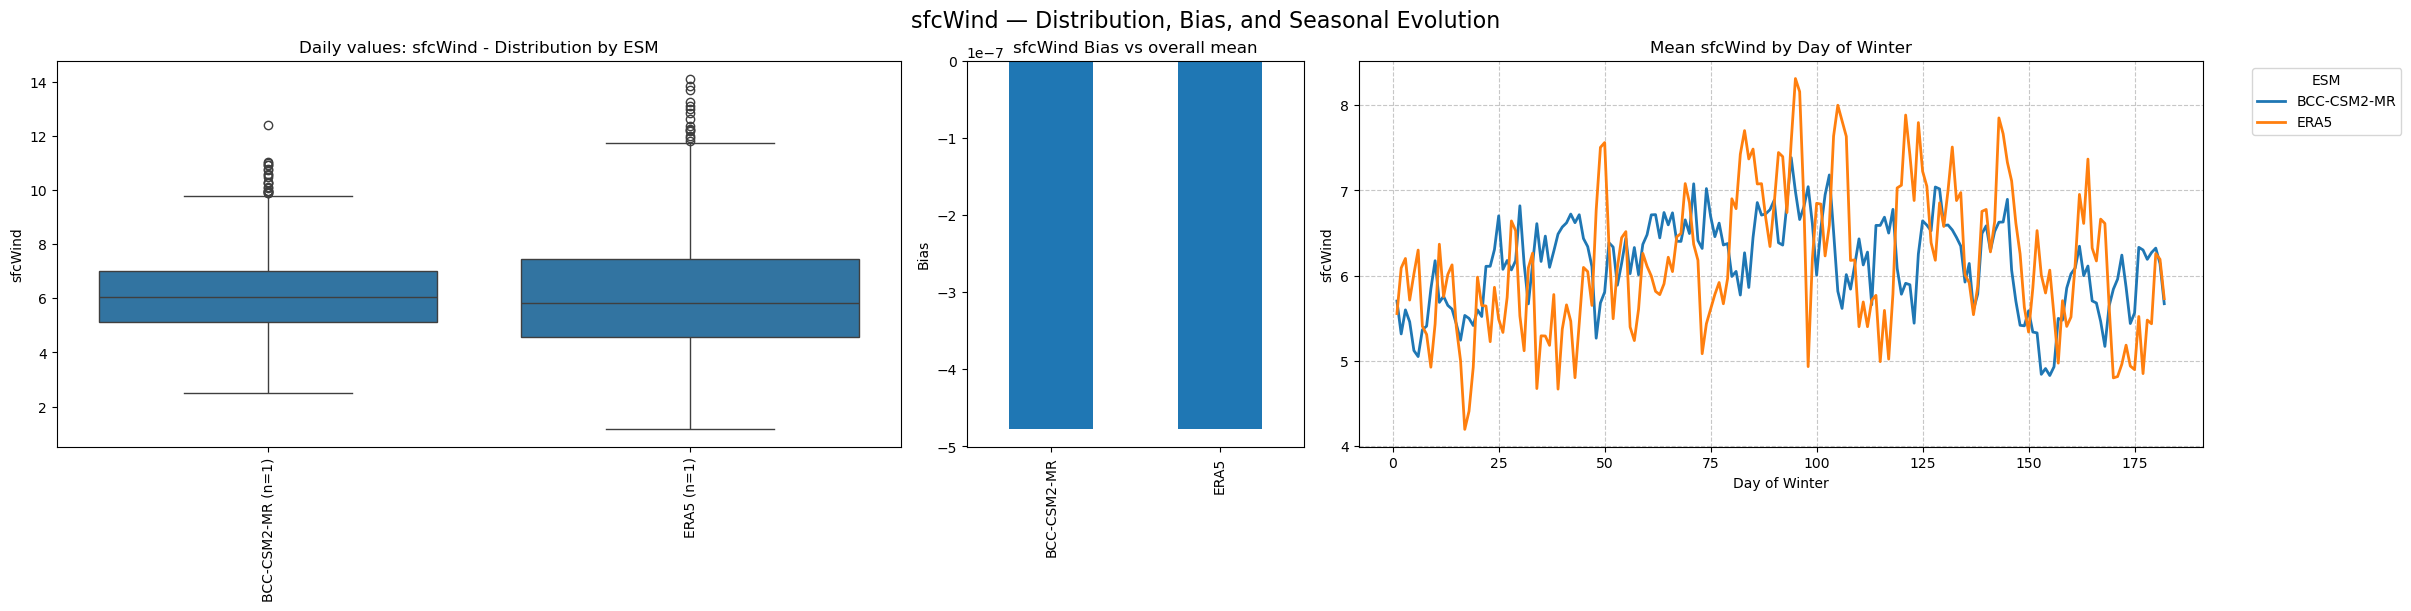

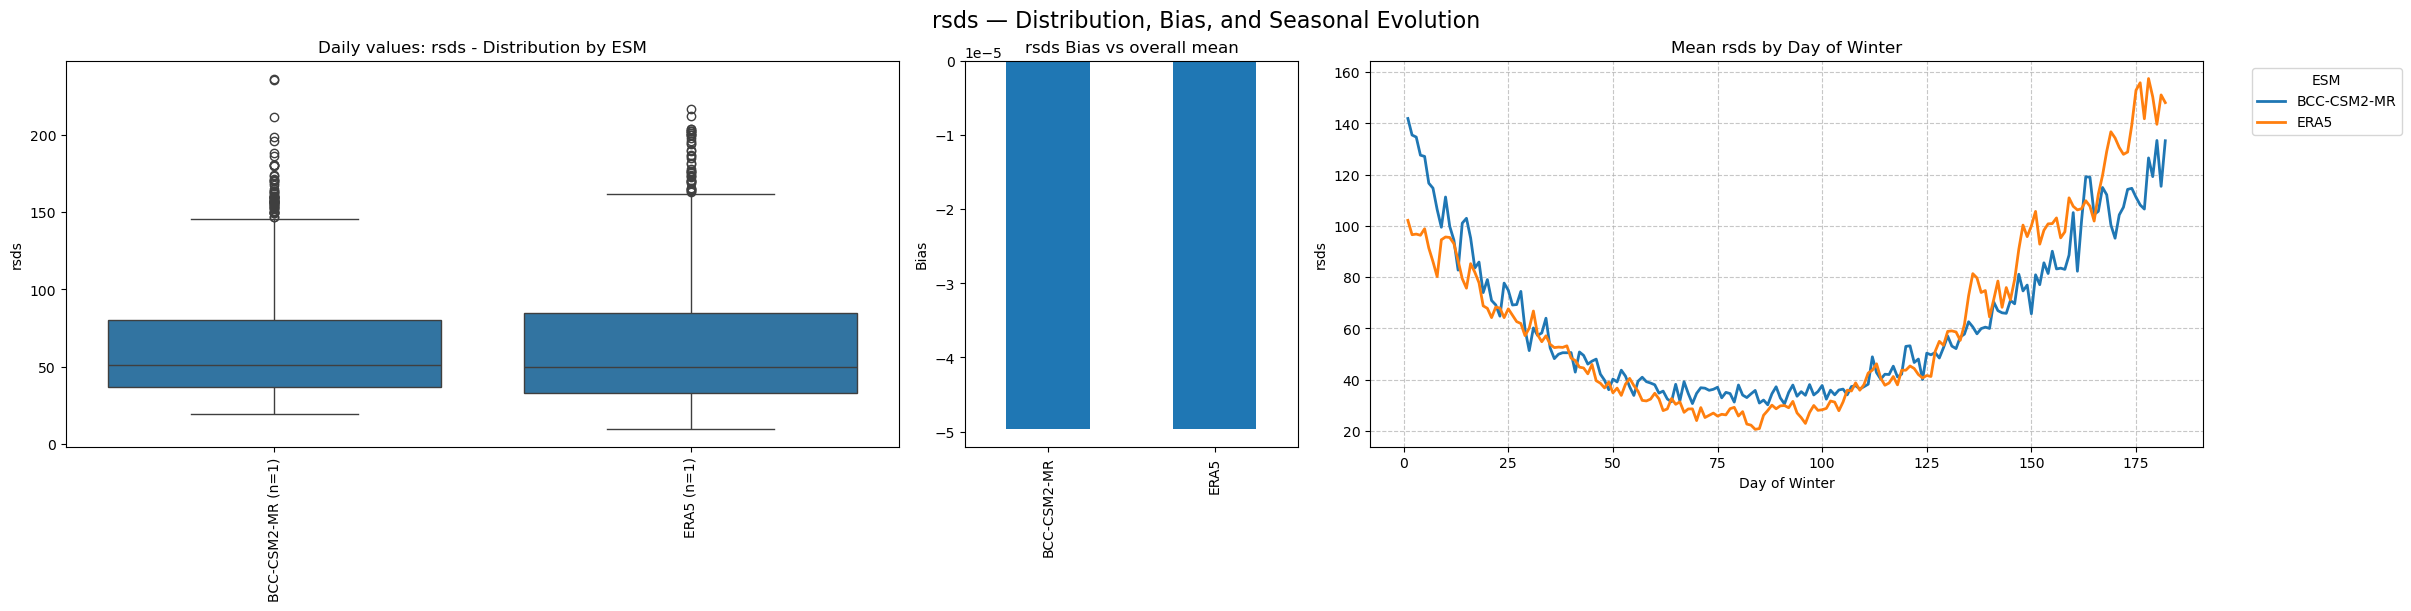

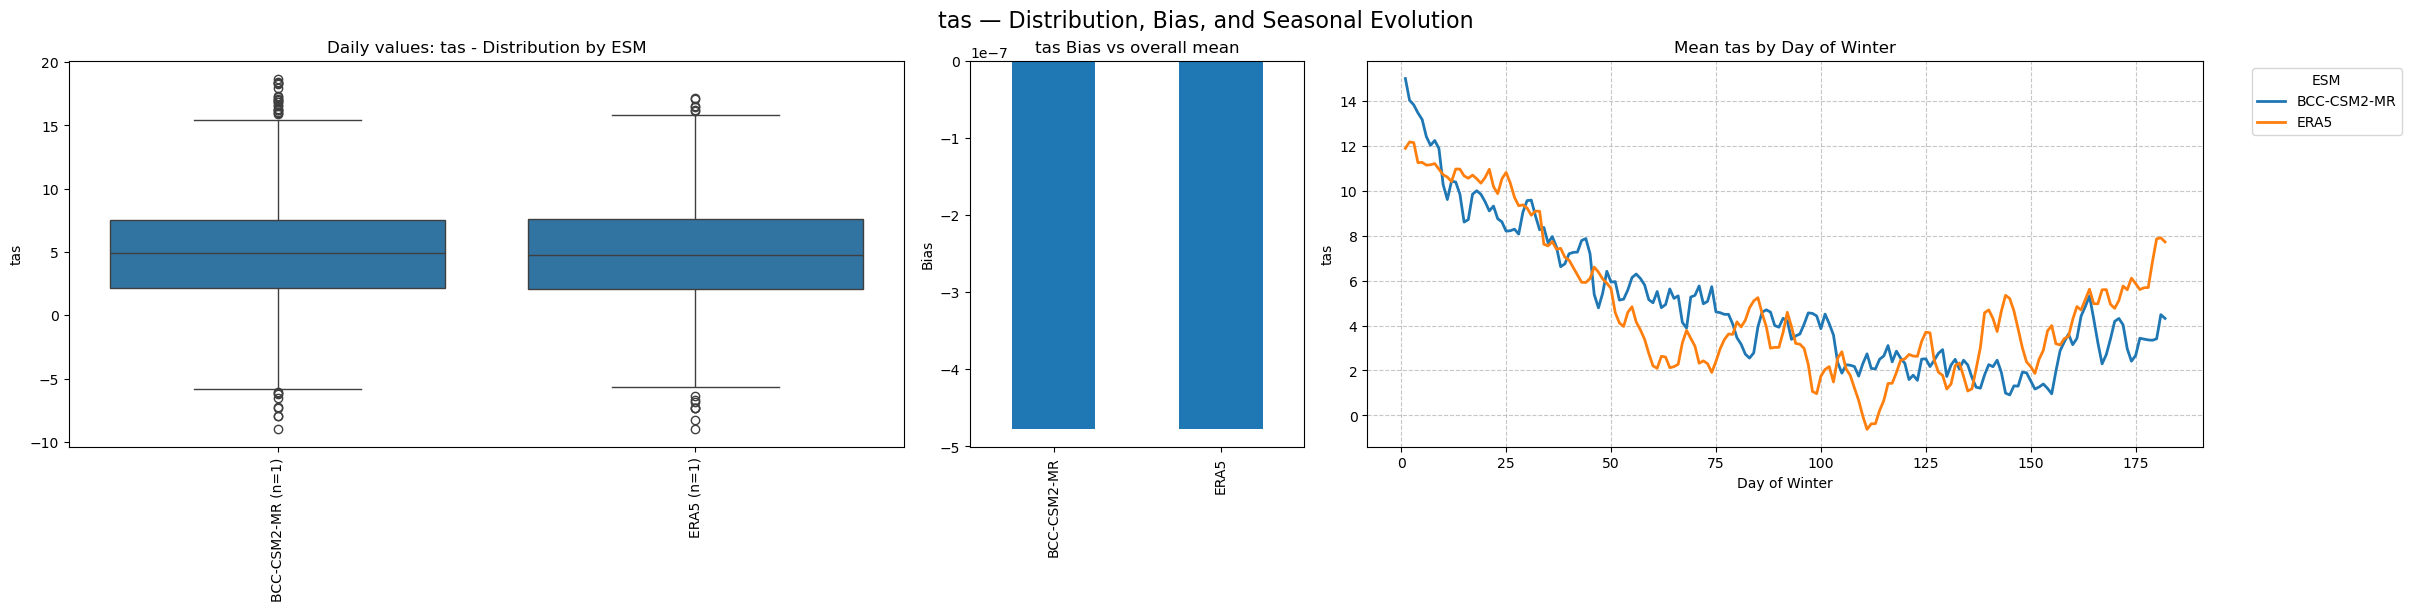

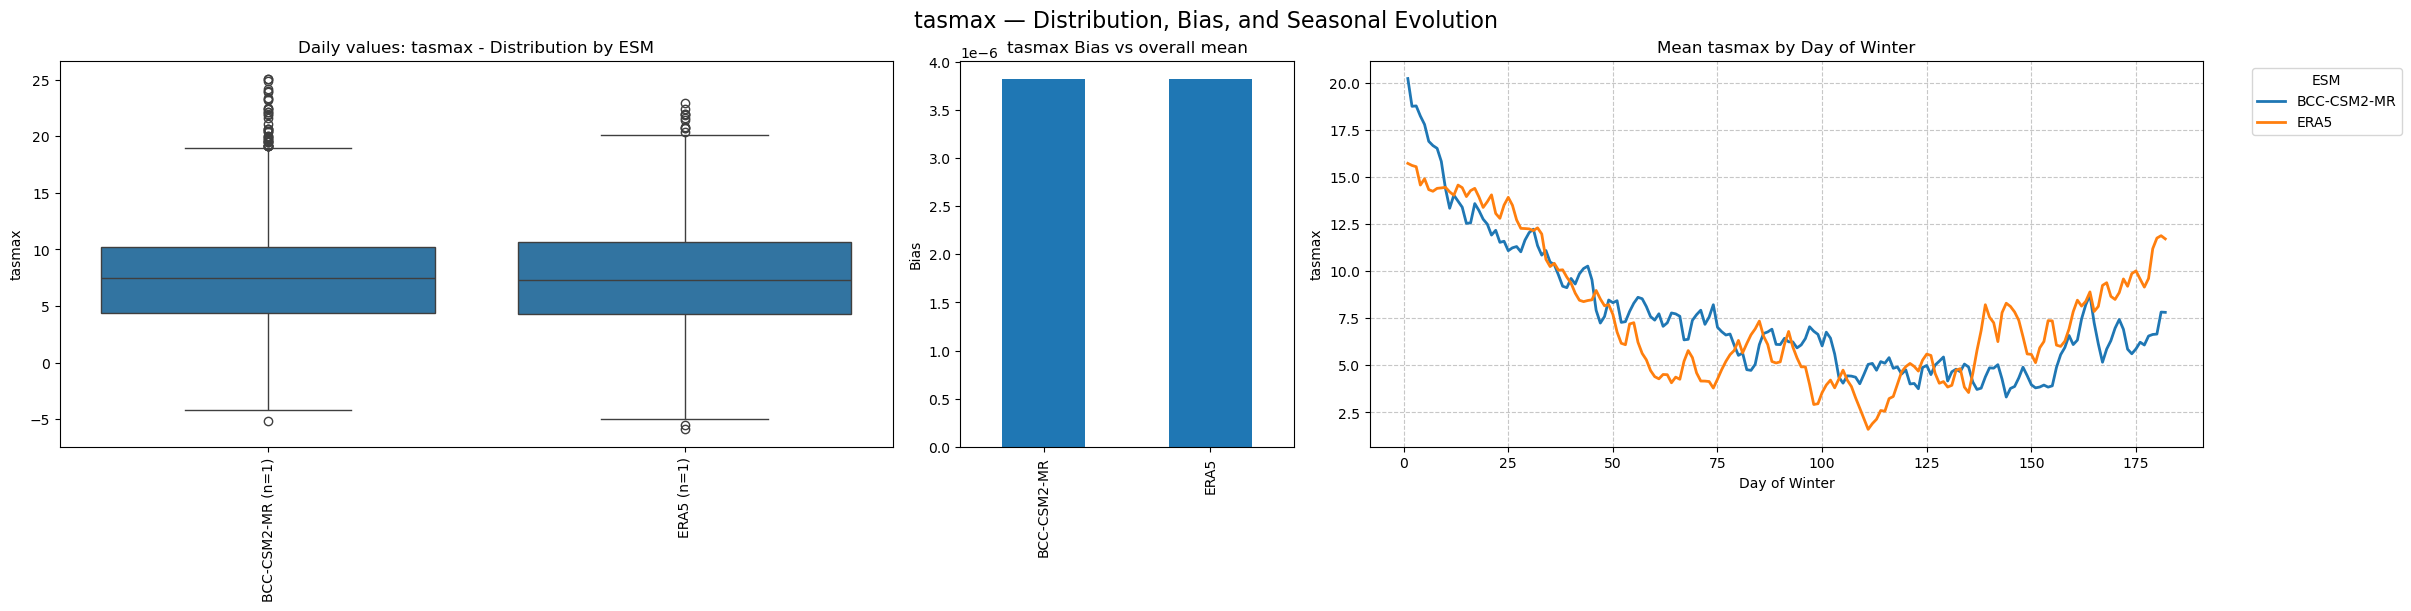

In [30]:

# Loop over variables and plot boxplot, bias, and seasonal lineplot
for var in variables:
    fig, axes = plt.subplots(
        1, 3,
        figsize=(24, 6),
        gridspec_kw={'width_ratios': [3, 1.2, 3]},
        constrained_layout=True
    )

    # 1. Boxplot (left)
    sns.boxplot(data=df, x='ESM_label', y=var, ax=axes[0])
    axes[0].set_title(f'Daily values: {var} - Distribution by ESM')
    axes[0].tick_params(axis='x', rotation=90)
    axes[0].set_xlabel('')
    axes[0].set_ylabel(var)

    # 2. Bias barplot (middle)

    model_mean = ts_datasets[var].groupby('ESM').mean().mean('time')
    overall_mean = ts_datasets[var].mean('time').mean()
    bias = model_mean - overall_mean

    bias.to_series().plot.bar(ax=axes[1])
    axes[1].set_title(f'{var} Bias vs overall mean')
    axes[1].set_ylabel('Bias')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=90)


    # 3. Line plot (right)

    if var in final_df.columns:
        for esm, group in final_df.groupby('ESM'):
            if esm == 'ERA5_week':
                axes[2].plot(group['day_of_winter'], group[var], color='red', linewidth=3, label='ERA5')
            elif esm == 'ERA5_wwd':
                axes[2].plot(group['day_of_winter'], group[var], color='red', linewidth=1, label='ERA5 wwd')
            else:
                axes[2].plot(group['day_of_winter'], group[var], linewidth=2, label=esm)

        axes[2].set_title(f'Mean {var} by Day of Winter')
        axes[2].set_xlabel('Day of Winter')
        axes[2].set_ylabel(var)
        axes[2].grid(True, linestyle='--', alpha=0.7)
        axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title='ESM')
    else:
        axes[2].text(0.5, 0.5, f'{var} not in final_df', ha='center', va='center')
        axes[2].set_axis_off()


    # Title
    plt.suptitle(f'{var} — Distribution, Bias, and Seasonal Evolution', fontsize=16)
    plt.show()


ESM:  BCC-CSM2-MR
Runs:  ['r1i1p1f1']
Run:  r1i1p1f1 Number:  1 of  1
Run time:  0 m 0.7 s
ESM:  BCC-CSM2-MR
Runs:  ['r1i1p1f1']
Run:  r1i1p1f1 Number:  1 of  1
Run time:  0 m 0.9 s


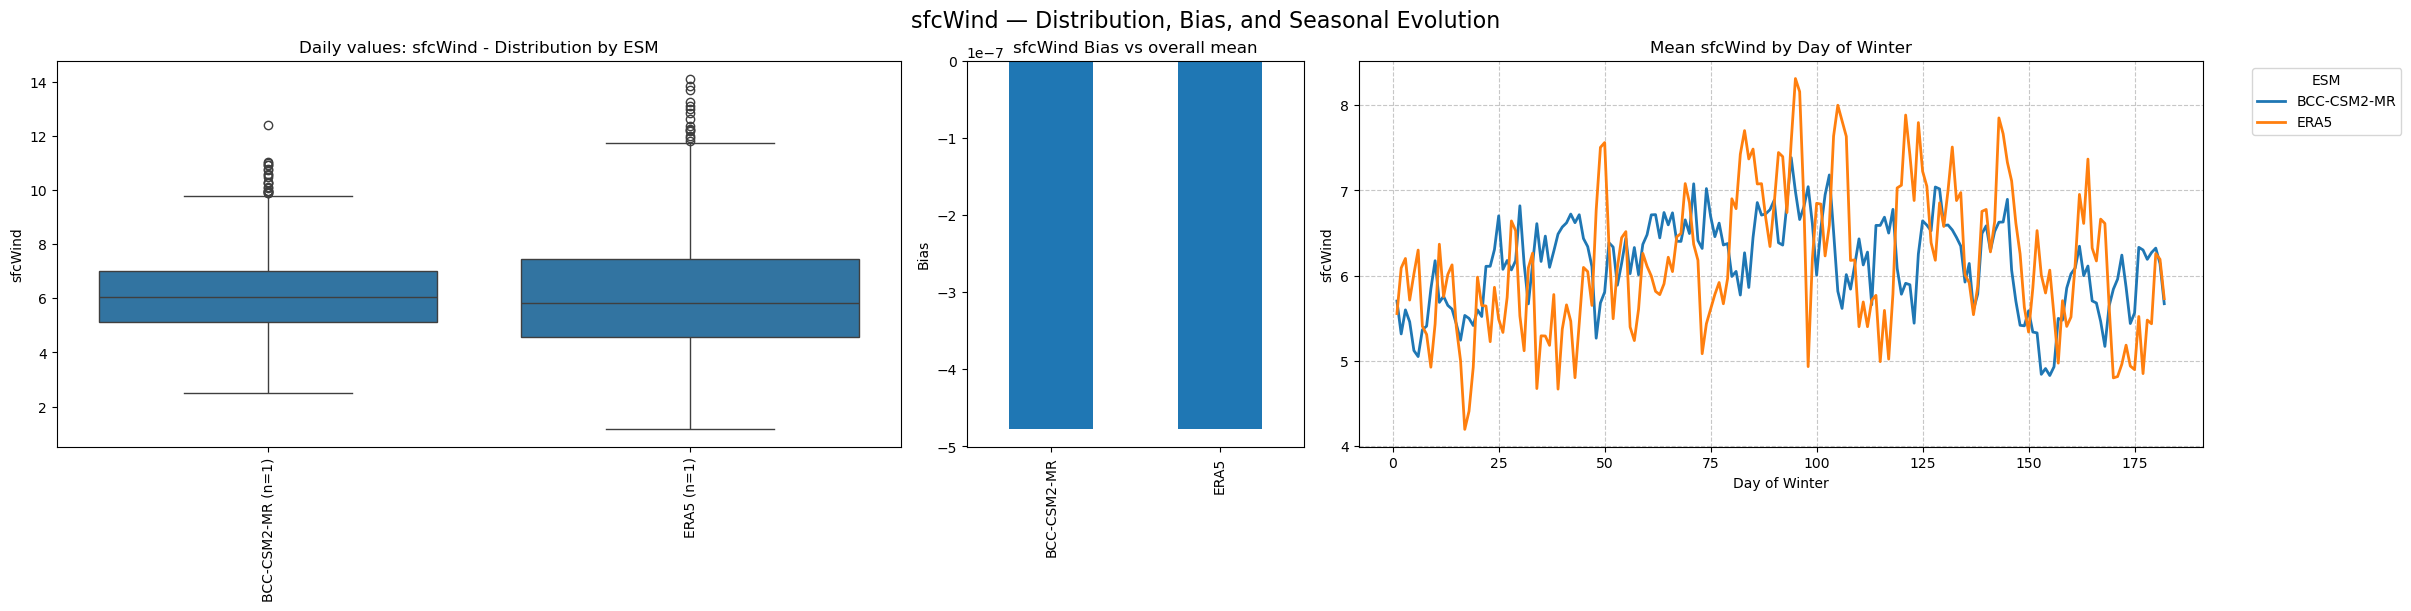

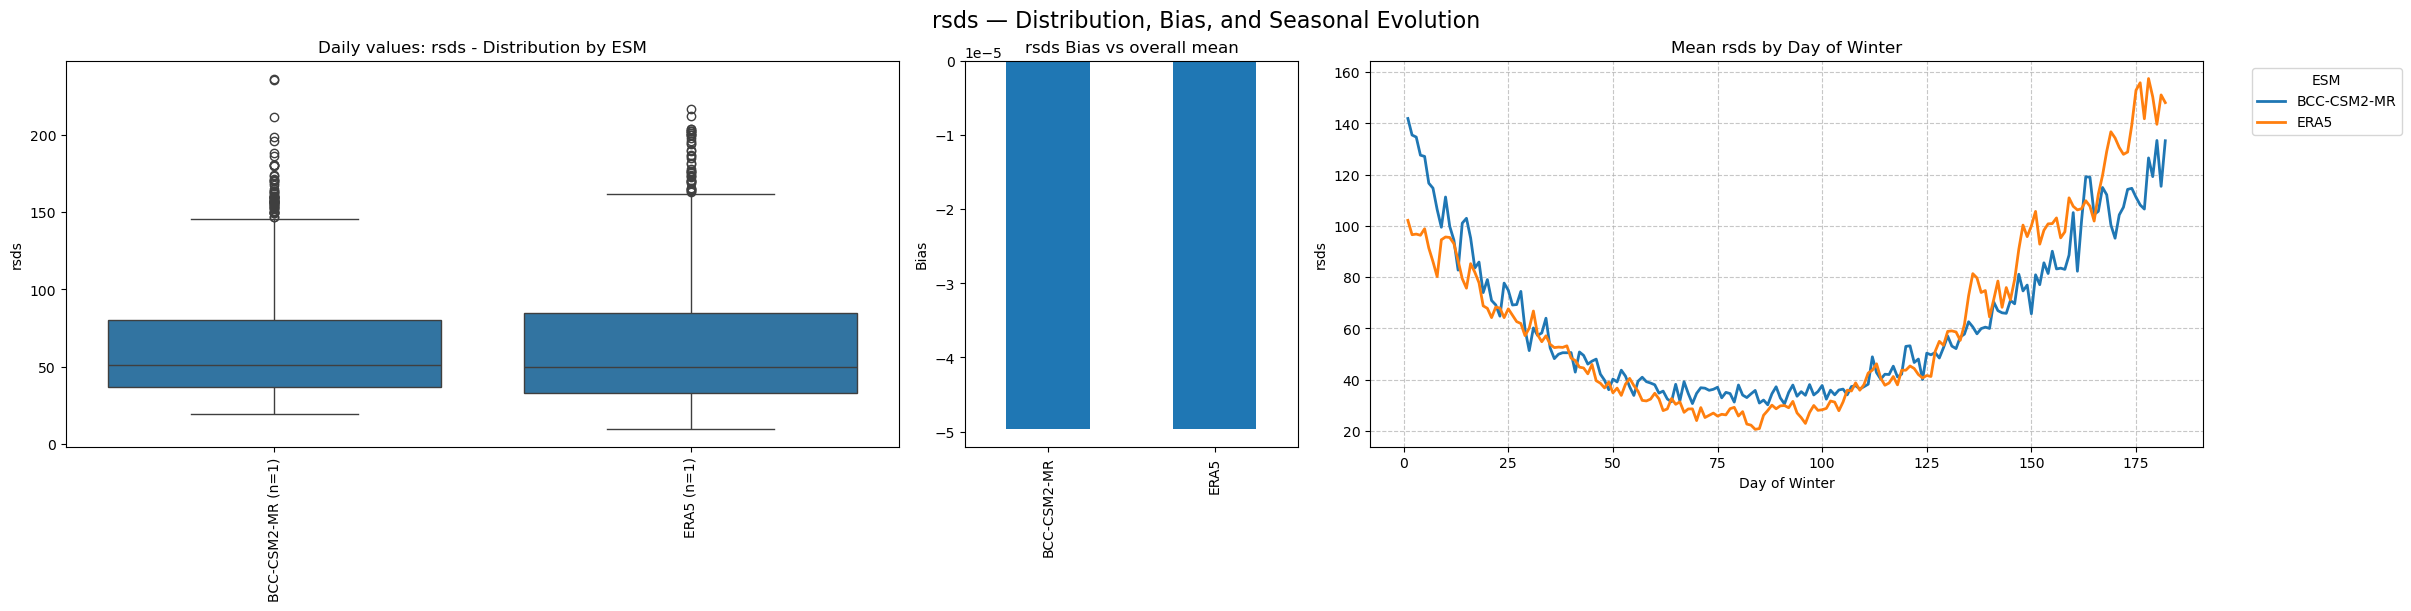

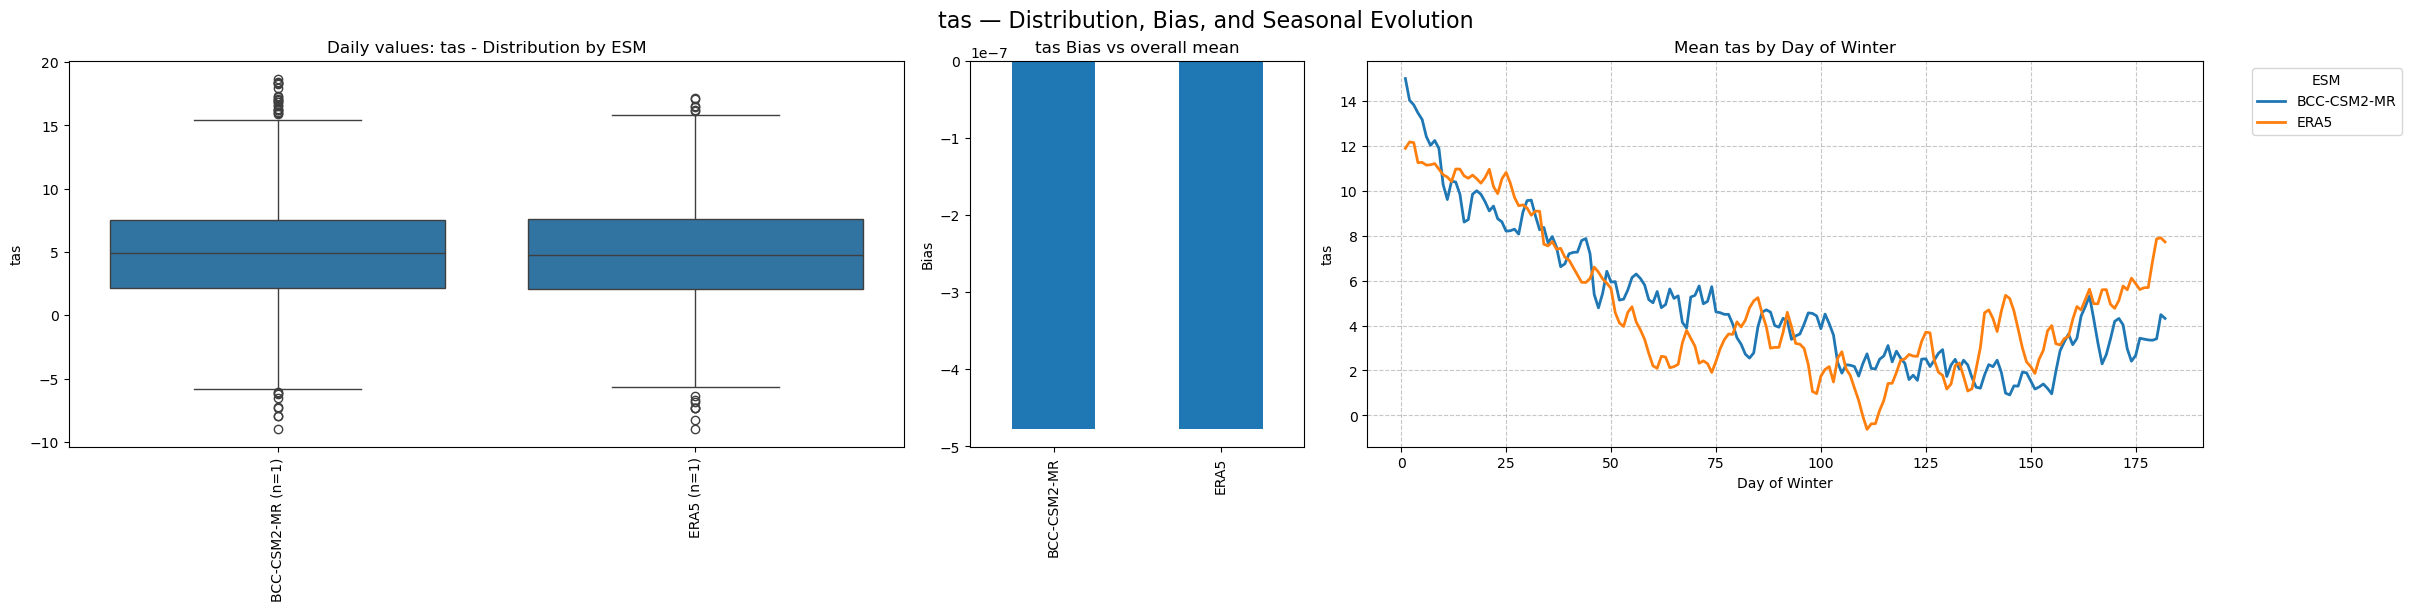

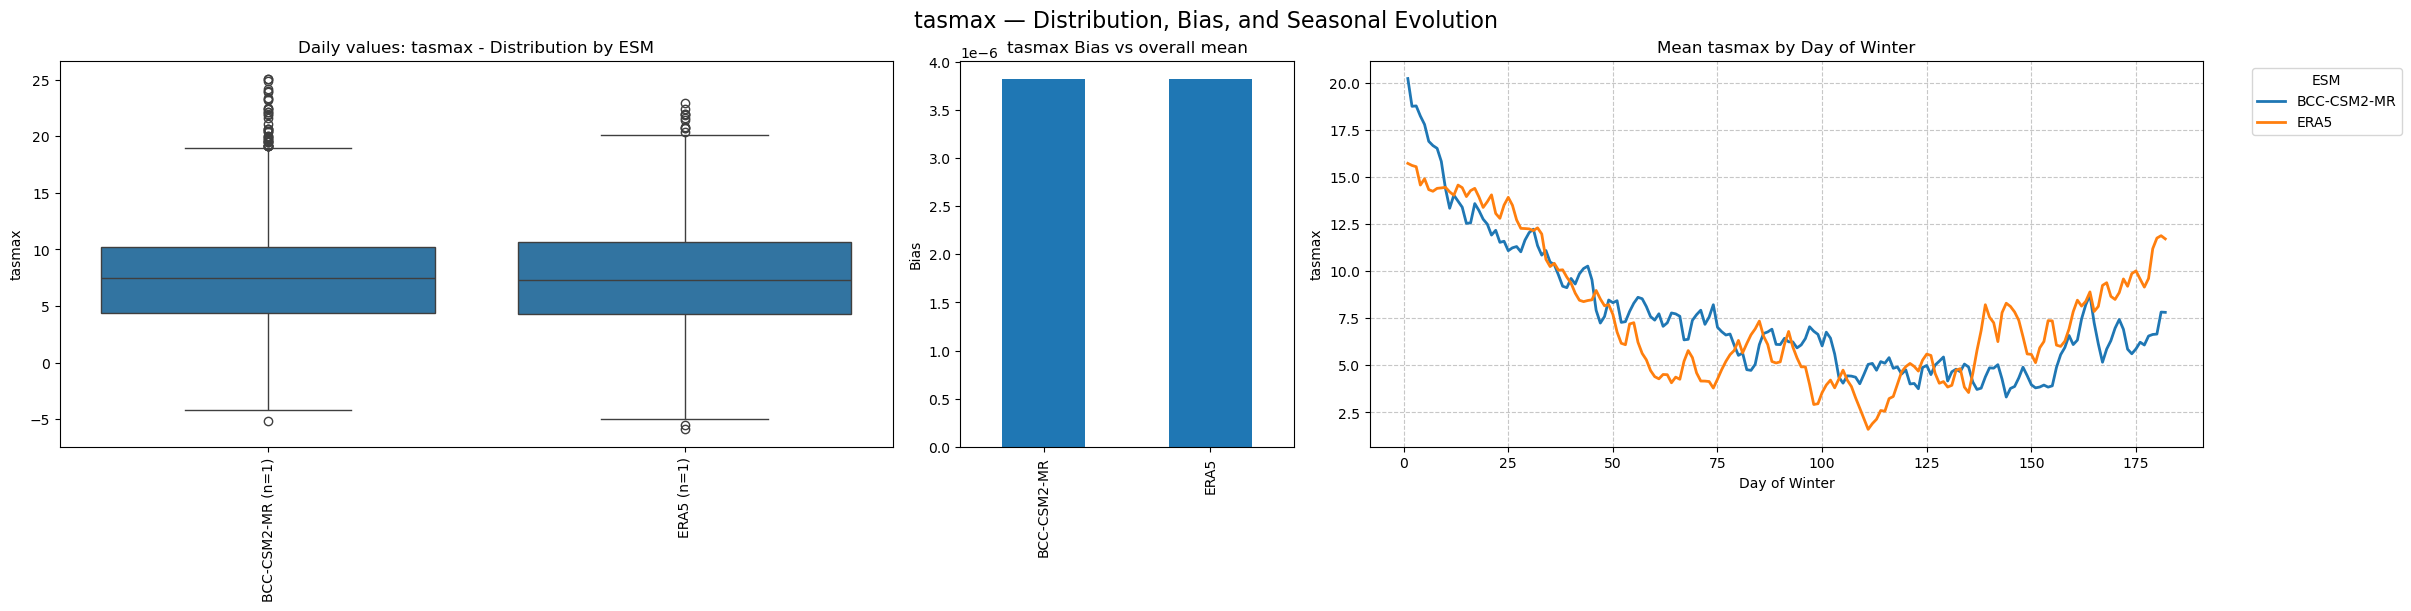

In [32]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import time
import re
import cftime

import Functions.grid_func as grid_func
import Functions.winter_date_func as winter_date_func
import Functions.wind_model_func as wind_model_func
import Functions.solar_model_func as solar_model_func
import Functions.demand as demand_func
import Functions.config as config

### Load datasets
# Load installed capacity data
grid_offshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic.nc')
grid_offshore = grid_offshore['wind_off_cap']
mask_offshore = xr.where(np.isfinite(grid_offshore), 1, 0)
grid_onshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic.nc')
grid_onshore = grid_onshore['wind_on_cap']
mask_onshore = xr.where(np.isfinite(grid_onshore), 1, 0)
grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic.nc')
grid_solar = grid_solar['solar_cap']
mask_solar = xr.where(np.isfinite(grid_solar), 1, 0)
population = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')
population = population['population']
mask_population = xr.where(np.isfinite(population), 1, 0)
# Overall mask
overall_mask = mask_offshore + mask_onshore + mask_solar + mask_population
overall_mask = xr.where(overall_mask > 0, 1, 0)
# mask
# Load climate data

MIP = 'ScenarioMIP' # CMIP
Institution = '*'
# ESMs = ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'GFDL-ESM4', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'KACE-1-0-G', 'TaiESM1', 'UKESM1-0-LL'] # 'EC-Earth3-Veg'
ESMs = ['BCC-CSM2-MR'] 

scenario = 'ssp370'
time_res = 'day'
variables = ['sfcWind', 'rsds', 'tas', 'tasmax'] # List of variables
grid_def = '*'
version = '*'
# Takes about 
for ESM in ESMs:
    print('ESM: ', ESM)
    path = f'/climca/data/CMIP6/{MIP}/{Institution}/{ESM}/{scenario}/'
    matching_dirs = glob.glob(path)
    if len(matching_dirs) == 1:
        runs = os.listdir(matching_dirs[0])
        # continue # Only for the last model
    elif len(matching_dirs) >= 1:
        runs = os.listdir(matching_dirs[0]) + os.listdir(matching_dirs[1])
    else:
        print(f"Found {len(matching_dirs)} matching directories for {ESM} and {scenario}")
        break
    print('Runs: ', runs)
    for run in runs:
        ds_list = [] # List to hold individual datasets (one for each variable)

        run_time = time.time()
        print('Run: ', run, 'Number: ', runs.index(run) + 1, 'of ', len(runs))
        run_path = os.path.join(matching_dirs[0], run, 'day/') # Watch out for last model (then manually change to matching_dirs[1])
        
        # Check if all required folders (in `variables`) exist
        missing_folders = [var for var in variables if not os.path.isdir(os.path.join(run_path, var))]
        
        if missing_folders:
            print(f"Missing folders in {run_path}: {missing_folders}")
            continue
        
        missing_data = [
            var for var in variables 
            if not os.path.isdir(os.path.join(run_path, var)) or 
               not any(
                   os.path.isfile(f) 
                   for f in glob.glob(os.path.join(run_path, var, '*', '*', '*'))  # glob pattern to match files two levels down
               )
        ]
        
        if missing_data:
            print(f"Missing data in {run_path}: {missing_data}")
            continue
        
        for variable in variables:
            # print('Variable: ', variable)
            #path =f'/climca/data/CMIP6/CMIP/NCAR/{ESM}/{scenario}/{run}/day/{variable}/gn/v20190308/{variable}_day_{ESM}_{scenario}_{run}_gn_*'
            path = f'/climca/data/CMIP6/{MIP}/{Institution}/{ESM}/{scenario}/{run}/{time_res}/{variable}/{grid_def}/{version}/{variable}_{time_res}_{ESM}_{scenario}_{run}_*'
            # print('Open: ', path)
            
            # Filter out files with extensions after .nc
            files = [f for f in glob.glob(path) if f.endswith('.nc')]
            
            # Open with preprocessing (spatial filtering)
            if files:
                nc = xr.open_mfdataset(files, preprocess=grid_func.preprocess)
            else:
                print("No valid .nc files found!")
            # nc = xr.open_mfdataset(path, preprocess=grid_func.preprocess)
                
        #     # Keep only the desired variable, but retain Dataset structure
            nc = nc[[variable]]

            # Filter years
            nc = nc.sel(time=nc.time.dt.year.isin(range(2015, 2025)))

        #     # Append to list for later merging
            ds_list.append(nc)
            
            ds_list = [ds.drop_vars('height') if 'height' in ds.coords else ds for ds in ds_list]

        # # Combine all into a single dataset
        clim_ds = xr.merge(ds_list)
                
        if ds_list[2]['tas'].units == 'K':
            clim_ds['tas'] = clim_ds['tas'] - 273.15
        
        if ds_list[3]['tasmax'].units == 'K':
            clim_ds['tasmax'] = clim_ds['tasmax'] - 273.15
        
        # Regrid the combined dataset
        combined_ds = grid_func.regrid(clim_ds)
        
        timeseries_ds = xr.Dataset()

        timeseries_ds['sfcWind_masked'] = combined_ds['sfcWind'].mean(dim=['lat', 'lon'])
        timeseries_ds['rsds_masked']    = combined_ds['rsds'].mean(dim=['lat', 'lon'])
        timeseries_ds['tas_masked']     = combined_ds['tas'].mean(dim=['lat', 'lon'])
        timeseries_ds['tasmax_masked']  = combined_ds['tasmax'].mean(dim=['lat', 'lon'])

        # timeseries_ds['sfcWind_masked'] = (combined_ds['sfcWind'] * overall_mask).mean(dim=['lat', 'lon'])
        # timeseries_ds['rsds_masked']    = (combined_ds['rsds'] * overall_mask).mean(dim=['lat', 'lon'])
        # timeseries_ds['tas_masked']     = (combined_ds['tas'] * overall_mask).mean(dim=['lat', 'lon'])
        # timeseries_ds['tasmax_masked']  = (combined_ds['tasmax'] * overall_mask).mean(dim=['lat', 'lon'])
        
        ts_output = timeseries_ds.assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')

        # print('Load')
        ts_output.load()
        # print('Saving')
        # ts_output.to_netcdf(f'/climca/people/onennecke/model_output/var_means/full_year/{ESM}_{run}_timeseries.nc')
        # ts_output.to_netcdf(f'/climca/people/onennecke/model_output/var_means_masked/full_year/{ESM}_{run}_timeseries.nc')
        
        print('Run time: ', int(np.floor((time.time()  - run_time) / 60)),'m', round((time.time()  - run_time) % 60,1),'s')
        # print('Finished saving')
    #     break
    # break

ts_ds_win_in = winter_date_func.add_winter_calendar(ts_output)
ts_win_in = ts_ds_win_in.sel(time=ts_ds_win_in['day_of_winter'].isin(range(1, 183)))

# Same for ERA5
variable = 't2m'
variables = ['U100', 'V100', 'SSRD', 'tas', 'tmax'] # List of variables
# path = f'/climca/data/ERA5/daily/{variables[3]}/' # Only for tmax und zum checken der anderen Variablen
path = '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/*'
matching_dirs = glob.glob(path)
all_files = [f for f in glob.glob(path) if f.endswith('.nc')]
all_files = sorted(all_files)
# Select all files in the range 2014-2024
path = '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/*'
year_range = (2015, 2024)
all_files = [f for f in glob.glob(path) if f.endswith('.nc')]
all_files = sorted(all_files)

filtered_files = []
for file in all_files:
    # Extract year and month using regex
    match = re.search(r'(\d{4})', file)
    if match:
        year = int(match.group(1))
        if year_range is None or year_range[0] <= year <= year_range[1]:
            filtered_files.append(file)

filtered_files

# Read datasets for each variable
files_by_variable = {}

# Group files by variable name
for f in filtered_files:
    match = re.search(r'/([^/]+)_(\d{4})\.nc$', f)
    if match:
        var = match.group(1)
        if var not in files_by_variable:
            files_by_variable[var] = []
        files_by_variable[var].append(f)

files_by_variable
# SSRD_list = files_by_variable['SSRD']
# SSRD_list

# Read datasets for each variable
datasets_by_variable = {}
for var, files in files_by_variable.items():
    # print(f'Processing {var}...')
    files_sorted = sorted(files)

    # Use the first file as coordinate reference
    ref_ds = xr.open_dataset(files_sorted[0])
    ref_lat = ref_ds.lat
    ref_lon = ref_ds.lon

    def preprocess(ds):
        ds = ds.sortby('lat')  # Ensure consistent order
        ds = ds.assign_coords(lat=ref_lat, lon=ref_lon)  # Align coordinates exactly
        return ds

    # Open and process all datasets with aligned coordinates
    ds = xr.open_mfdataset(files_sorted, combine='by_coords', preprocess=preprocess)
    
    if var == 'SSRD':
        ds = ds / 3600 # Convert from J/m2 to W/m2
    ds_daily = ds.resample(time='1D').mean()
    datasets_by_variable[var] = ds_daily
    if var == 'tas':
        tasmax = ds.resample(time='1D').max()
        tasmax = tasmax.rename({'var167': 'tasmax'})
        datasets_by_variable['tasmax'] = tasmax


datasets_by_variable

var_names = {'var169': 'rsds',
             'var167': 'tas',
             'var246': 'U100',
             'var247': 'V100',
             'tasmax': 'tasmax'}

ds_list = []

for i in datasets_by_variable:
    ds = datasets_by_variable[i]
    var = list(ds.data_vars)[0]
    ds = ds.rename({var: var_names[var]})
    ds = ds.sel(lat=slice(45, 60), lon=slice(4, 17))
    nc = grid_func.regrid(ds, s = 47, n = 56, w = 5, e = 17) # One ° less in the north to prevent NaN values
    # Append to list for later merging
    ds_list.append(nc)

# Read in tmax

# Combine all into a single dataset
clim_ds = xr.merge(ds_list)

clim_ds['wind_speed'] = np.sqrt(clim_ds['U100']**2 + clim_ds['V100']**2)
clim_ds['tas'] = clim_ds['tas'] - 273.15
clim_ds['tasmax'] = clim_ds['tasmax'] - 273.15

combined_ds = clim_ds
combined_ds

timeseries_ds = xr.Dataset()

timeseries_ds['sfcWind_masked'] = combined_ds['wind_speed'].mean(dim=['lat', 'lon'])
timeseries_ds['rsds_masked']    = combined_ds['rsds'].mean(dim=['lat', 'lon'])
timeseries_ds['tas_masked']     = combined_ds['tas'].mean(dim=['lat', 'lon'])
timeseries_ds['tasmax_masked']  = combined_ds['tasmax'].mean(dim=['lat', 'lon'])

# timeseries_ds['sfcWind_masked'] = (combined_ds['wind_speed'] * overall_mask).mean(dim=['lat', 'lon'])
# timeseries_ds['rsds_masked']    = (combined_ds['rsds'] * overall_mask).mean(dim=['lat', 'lon'])
# timeseries_ds['tas_masked']     = (combined_ds['tas'] * overall_mask).mean(dim=['lat', 'lon'])
# timeseries_ds['tasmax_masked']  = (combined_ds['tasmax'] * overall_mask).mean(dim=['lat', 'lon'])

ts_output = timeseries_ds.assign_coords(run = 'hist', ESM = 'ERA5', ESM_run = 'ERA5_hist') # , country = 9.0, period = 'week'
# print('Load')
ts_output.load()
# print('Saving')
# ts_output.to_netcdf('/climca/people/onennecke/model_output/var_means_masked/full_year/ERA5_timeseries.nc')


# print('Finished saving')

ts_ds_win_ERA5 = winter_date_func.add_winter_calendar(ts_output)
ts_win_ERA5 = ts_ds_win_ERA5.sel(time=ts_ds_win_ERA5['day_of_winter'].isin(range(1, 183)))

## Fix time format for ERA5
ts_win_ERA5 = ts_win_ERA5.assign_coords(time=ts_win_in['time'].values)
# Combine both datasets
ts_datasets = xr.concat([ts_win_in, ts_win_ERA5], dim='ESM_run')
ts_datasets
all_dfs = []
variables = [
    'sfcWind_masked', 'rsds_masked', 'tas_masked', 'tasmax_masked' # , 'temp', 'demand', 'demand_weekly', 'wind_off_prod', 'wind_on_prod', 'solar_prod', 'total_prod', 'Residual_load'
]
for var in variables:
    ERA5_mean = ts_datasets[var].sel(ESM_run='ERA5_hist').mean('time')
    model_mean = ts_datasets[var].groupby('ESM').mean().mean('time')
    # overall_mean = ts_datasets[var].mean('time').mean()
    
    overall_mean = ts_datasets[var].mean('time').mean('ESM_run')
    
    bias = model_mean - ERA5_mean
    
    df_bias = pd.DataFrame({
        'ESM': np.unique(ts_datasets['ESM'].values),
        # 'ERA5_mean': ERA5_mean.values,
        f'model_mean_{var}': model_mean.values,
        f'overall_mean_{var}': overall_mean.values,
        f'bias_{var}': bias.values
    })
    all_dfs.append(df_bias)
final_df_bias = pd.concat(all_dfs, axis=1, ignore_index=False)
final_df_bias = final_df_bias.loc[:,~final_df_bias.columns.duplicated()]
final_df_bias


### Load datasets
# Load installed capacity data
grid_offshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic.nc')
grid_offshore = grid_offshore['wind_off_cap']
mask_offshore = xr.where(np.isfinite(grid_offshore), 1, 0)
grid_onshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic.nc')
grid_onshore = grid_onshore['wind_on_cap']
mask_onshore = xr.where(np.isfinite(grid_onshore), 1, 0)
grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic.nc')
grid_solar = grid_solar['solar_cap']
mask_solar = xr.where(np.isfinite(grid_solar), 1, 0)
population = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')
population = population['population']
mask_population = xr.where(np.isfinite(population), 1, 0)
# Overall mask
overall_mask = mask_offshore + mask_onshore + mask_solar + mask_population
overall_mask = xr.where(overall_mask > 0, 1, 0)
# Load wind height data
grid_onsh_hub_height = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_height_weighted.nc')
grid_offsh_hub_height = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted.nc')

hub_height_on = grid_onsh_hub_height['wind_on_hub_height']
hub_height_off = grid_offsh_hub_height['wind_off_hub_height']
# Load regridded population weights data
pop_regr_CIESIN_weights = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')

# Load fit values from vdW Paper
demand_fit_values = xr.open_dataset('/climca/people/onennecke/population_data/demand_fit_values_week.nc')
# Load bias data
# biases = pd.read_csv('/climca/people/onennecke/model_output/var_means/biases.csv')
biases = final_df_bias# pd.read_csv('/climca/people/onennecke/model_output/var_means_masked/biases.csv')

biases
### Define used models
# Load climate data

MIP = 'ScenarioMIP' # CMIP
Institution = '*'

# ESMs = ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'GFDL-ESM4', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'KACE-1-0-G', 'TaiESM1', 'UKESM1-0-LL'] # 'EC-Earth3-Veg'
ESMs = ['BCC-CSM2-MR'] # 'EC-Earth3-Veg'

scenario = 'ssp370'
time_res = 'day'
variables = ['sfcWind', 'rsds', 'tas', 'tasmax'] # List of variables
grid_def = '*'
version = '*'

# Takes about 
for ESM in ESMs:
    print('ESM: ', ESM)
    path = f'/climca/data/CMIP6/{MIP}/{Institution}/{ESM}/{scenario}/'
    matching_dirs = glob.glob(path)
    if len(matching_dirs) == 1:
        runs = os.listdir(matching_dirs[0])
        # continue # Only for the last model
    elif len(matching_dirs) >= 1:
        runs = os.listdir(matching_dirs[0]) + os.listdir(matching_dirs[1])
    else:
        print(f"Found {len(matching_dirs)} matching directories for {ESM} and {scenario}")
        break
    print('Runs: ', runs)
    for run in runs:
        ds_list = [] # List to hold individual datasets (one for each variable)

        run_time = time.time()
        print('Run: ', run, 'Number: ', runs.index(run) + 1, 'of ', len(runs))
        run_path = os.path.join(matching_dirs[0], run, 'day/') # Watch out for last model (then manually change to matching_dirs[1])
        
        # Check if all required folders (in `variables`) exist
        missing_folders = [var for var in variables if not os.path.isdir(os.path.join(run_path, var))]
        
        if missing_folders:
            print(f"Missing folders in {run_path}: {missing_folders}")
            continue
        
        missing_data = [
            var for var in variables 
            if not os.path.isdir(os.path.join(run_path, var)) or 
               not any(
                   os.path.isfile(f) 
                   for f in glob.glob(os.path.join(run_path, var, '*', '*', '*'))  # glob pattern to match files two levels down
               )
        ]
        
        if missing_data:
            print(f"Missing data in {run_path}: {missing_data}")
            continue
        
        for variable in variables:
            # print('Variable: ', variable)
            #path =f'/climca/data/CMIP6/CMIP/NCAR/{ESM}/{scenario}/{run}/day/{variable}/gn/v20190308/{variable}_day_{ESM}_{scenario}_{run}_gn_*'
            path = f'/climca/data/CMIP6/{MIP}/{Institution}/{ESM}/{scenario}/{run}/{time_res}/{variable}/{grid_def}/{version}/{variable}_{time_res}_{ESM}_{scenario}_{run}_*'
            # print('Open: ', path)
            
            # Filter out files with extensions after .nc
            files = [f for f in glob.glob(path) if f.endswith('.nc')]
            
            # Open with preprocessing (spatial filtering)
            if files:
                nc = xr.open_mfdataset(files, preprocess=grid_func.preprocess)
            else:
                print("No valid .nc files found!")
            # nc = xr.open_mfdataset(path, preprocess=grid_func.preprocess)
                
        #     # Keep only the desired variable, but retain Dataset structure
            nc = nc[[variable]]
            
            
        #     # Filter to only winter months (October to March)
        #     # nc = nc.sel(time=nc.time.dt.month.isin([10, 11, 12, 1, 2, 3]))

            # Filter years
            nc = nc.sel(time=nc.time.dt.year.isin(range(2015, 2025)))
            
        #     # Append to list for later merging
            ds_list.append(nc)
            
            ds_list = [ds.drop_vars('height') if 'height' in ds.coords else ds for ds in ds_list]

        # # Combine all into a single dataset
        clim_ds = xr.merge(ds_list)
                
        if ds_list[2]['tas'].units == 'K':
            clim_ds['tas'] = clim_ds['tas'] - 273.15
        
        if ds_list[3]['tasmax'].units == 'K':
            clim_ds['tasmax'] = clim_ds['tasmax'] - 273.15
            
        # Apply bias correction
        clim_ds['sfcWind'] = clim_ds['sfcWind'] - biases.loc[biases['ESM'] == ESM, 'bias_sfcWind_masked'].values[0]
        clim_ds['rsds'] = clim_ds['rsds'] - biases.loc[biases['ESM'] == ESM, 'bias_rsds_masked'].values[0]
        clim_ds['tas'] = clim_ds['tas'] - biases.loc[biases['ESM'] == ESM, 'bias_tas_masked'].values[0]
        clim_ds['tasmax'] = clim_ds['tasmax'] - biases.loc[biases['ESM'] == ESM, 'bias_tasmax_masked'].values[0]
            
        # Regrid the combined dataset
        combined_ds = grid_func.regrid(clim_ds)
        
        wepot_off = wind_model_func.compute_wind_energy_potential(combined_ds['sfcWind'], grid_offsh_hub_height, config.a_offshore, config.height_ref)
        wepot_on = wind_model_func.compute_wind_energy_potential(combined_ds['sfcWind'], grid_onsh_hub_height, config.a_onshore, config.height_ref)
        
        combined_ds['wind_off_pot'] = wepot_off['wind_off_pot']
        combined_ds['wind_on_pot'] = wepot_on['wind_on_pot']
        
        weprod_off = wind_model_func.compute_wind_energy_production(wepot_off, grid_offshore)
        weprod_on = wind_model_func.compute_wind_energy_production(wepot_on, grid_onshore)
        
        combined_ds['wind_off_prod'] = weprod_off['wind_off_prod']
        combined_ds['wind_on_prod'] = weprod_on['wind_on_prod']
        
        sepot = solar_model_func.compute_solar_energy_potential(combined_ds['rsds'], combined_ds['tas'], combined_ds['tasmax'], combined_ds['sfcWind'])
        
        # combined_ds['solar_pot'] = sepot['solar_pot']        
        combined_ds['solar_pot'] = sepot
        
        seprod = solar_model_func.compute_solar_energy_production(sepot, grid_solar)
        
        # combined_ds['solar_prod'] = seprod['solar_prod']
        combined_ds['solar_prod'] = seprod

        
        # Calculate weighted sum

        weighted_temp_list = []
        for y in np.unique(combined_ds['tas']["time.year"].values):
            # print(y)
            ds_weigh_temp_0 = xr.Dataset()
            ds_weigh_temp_0['temp'] = (combined_ds['tas'].sel(time=str(y)) * pop_regr_CIESIN_weights['population']).sum(dim=['lat', 'lon'])
            weighted_temp_list.append(ds_weigh_temp_0)
            
        ds_weighted_temp = xr.concat(weighted_temp_list, dim="time") 
        
        # Calculate demand
        demand_ds = demand_func.compute_demand(ds_weighted_temp, demand_fit_values.sel(country = 9, period = 'week'))
        
        timeseries_ds = demand_ds.copy()

        timeseries_ds['sfcWind'] = combined_ds['sfcWind'].mean(dim=['lat', 'lon'])
        timeseries_ds['rsds'] = combined_ds['rsds'].mean(dim=['lat', 'lon'])
        timeseries_ds['tas'] = combined_ds['tas'].mean(dim=['lat', 'lon'])
        timeseries_ds['tasmax'] = combined_ds['tasmax'].mean(dim=['lat', 'lon'])
        
        # timeseries_ds['sfcWind'] = (combined_ds['sfcWind'] * overall_mask).mean(dim=['lat', 'lon'])
        # timeseries_ds['rsds']    = (combined_ds['rsds'] * overall_mask).mean(dim=['lat', 'lon'])
        # timeseries_ds['tas']     = (combined_ds['tas'] * overall_mask).mean(dim=['lat', 'lon'])
        # timeseries_ds['tasmax']  = (combined_ds['tasmax'] * overall_mask).mean(dim=['lat', 'lon'])
        
        timeseries_ds['wind_off_prod'] = combined_ds['wind_off_prod'].sum(dim=['lat', 'lon']) / 1000000
        timeseries_ds['wind_on_prod'] = combined_ds['wind_on_prod'].sum(dim=['lat', 'lon']) / 1000000
        timeseries_ds['solar_prod'] = combined_ds['solar_prod'].sum(dim=['lat', 'lon']) / 1000000
        
        timeseries_ds['total_prod'] = timeseries_ds['wind_off_prod'] + timeseries_ds['wind_on_prod'] + timeseries_ds['solar_prod']
        timeseries_ds['Netto'] = timeseries_ds['total_prod'] - timeseries_ds['demand']
        timeseries_ds['Residual_load'] = timeseries_ds['demand'] - timeseries_ds['total_prod']
        
        ts_output = timeseries_ds.assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')
        # print('Load')
        ts_output.load()
        # print('Saving')
        # ts_output.to_netcdf(f'/climca/people/onennecke/model_output/bias_corrected/full_year/{ESM}_{run}_timeseries.nc')
        # ts_output.to_netcdf(f'/climca/people/onennecke/model_output/bias_corrected_masked/full_year/{ESM}_{run}_timeseries.nc')
        
        print('Run time: ', int(np.floor((time.time()  - run_time) / 60)),'m', round((time.time()  - run_time) % 60,1),'s')
        # print('Finished saving')
    #     break
    # break
ts_output

ts_ds_win_in = winter_date_func.add_winter_calendar(ts_output)
ts_win_in = ts_ds_win_in.sel(time=ts_ds_win_in['day_of_winter'].isin(range(1, 183)))
ts_win_in

# path = '/climca/people/onennecke/model_output/var_means_masked/winter_data/'
path = '/climca/people/onennecke/model_output/var_means/winter_data/'

files = sorted(glob.glob(os.path.join(path, '*.nc')))
files = files[60]#  + files[61:]
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')
# files

# Rename variables without _masked
# ts_datasets = ts_datasets.rename({
#     'sfcWind_masked': 'sfcWind',
#     'rsds_masked': 'rsds',
#     'tas_masked': 'tas',
#     'tasmax_masked': 'tasmax'
# })
ts_datasets['time'] = ts_win_in['time']

ts_datasets.load()
ts_datasets = xr.concat([ts_win_in, ts_datasets], dim='ESM_run')
ts_datasets
# Group data by ESMs and calculate mean temp, demand, wind, ...
all_dfs = []
for esm in np.unique(ts_datasets['ESM'].values):
    filtered_dataset = ts_datasets.where(ts_datasets['ESM'] == esm, drop=True)
    mean_by_day = filtered_dataset.groupby('day_of_winter').mean(dim=['time', 'ESM_run'])
    df = pd.DataFrame({
        'day_of_winter': mean_by_day['day_of_winter'].values,
        'temp': mean_by_day['temp'].values,
        'demand': mean_by_day['demand'].values,
        # 'demand_weekly': mean_by_day['demand_weekly'].values,
        'sfcWind': mean_by_day['sfcWind'].values,
        'rsds' : mean_by_day['rsds'].values,
        'tas': mean_by_day['tas'].values,
        'tasmax': mean_by_day['tasmax'].values,
        'wind_off_prod': mean_by_day['wind_off_prod'].values,
        'wind_on_prod': mean_by_day['wind_on_prod'].values,
        'solar_prod': mean_by_day['solar_prod'].values,
        'total_prod': mean_by_day['total_prod'].values,
        'netto': mean_by_day['Netto'].values,
        'Residual_load': mean_by_day['Residual_load'].values,
    })
    df['ESM'] = esm
    all_dfs.append(df)

final_df = pd.concat(all_dfs, ignore_index=True)

final_df
# For Boxplots per model
df = ts_datasets.to_dataframe().reset_index()

variables = [
    'sfcWind', 'rsds', 'tas', 'tasmax', 'temp', 'demand',
    'wind_off_prod', 'wind_on_prod', 'solar_prod',
    'total_prod', 'Residual_load'
]

# Compute ESM counts once and create labels
esm_counts = (df['ESM'].value_counts().sort_index() // 1820).astype(int)
esm_label_map = {esm: f"{esm} (n={count})" for esm, count in esm_counts.items()}
df['ESM_label'] = df['ESM'].map(esm_label_map)
all_dfs = []
variables = [
    'sfcWind', 'rsds', 'tas', 'tasmax' # , 'temp', 'demand', 'demand_weekly', 'wind_off_prod', 'wind_on_prod', 'solar_prod', 'total_prod', 'Residual_load'
]
for var in variables:
    ERA5_mean = ts_datasets[var].sel(ESM_run='ERA5_hist').mean('time')
    model_mean = ts_datasets[var].groupby('ESM').mean().mean('time')
    # overall_mean = ts_datasets[var].mean('time').mean()
    
    overall_mean = ts_datasets[var].mean('time').mean('ESM_run')
    
    bias = model_mean - ERA5_mean
    
    df_bias = pd.DataFrame({
        'ESM': np.unique(ts_datasets['ESM'].values),
        # 'ERA5_mean': ERA5_mean.values,
        f'model_mean_{var}': model_mean.values,
        f'overall_mean_{var}': overall_mean.values,
        f'bias_{var}': bias.values
    })
    all_dfs.append(df_bias)
final_df_bias = pd.concat(all_dfs, axis=1, ignore_index=False)
final_df_bias = final_df_bias.loc[:,~final_df_bias.columns.duplicated()]
final_df_bias

# Loop over variables and plot boxplot, bias, and seasonal lineplot
for var in variables:
    fig, axes = plt.subplots(
        1, 3,
        figsize=(24, 6),
        gridspec_kw={'width_ratios': [3, 1.2, 3]},
        constrained_layout=True
    )

    # 1. Boxplot (left)
    sns.boxplot(data=df, x='ESM_label', y=var, ax=axes[0])
    axes[0].set_title(f'Daily values: {var} - Distribution by ESM')
    axes[0].tick_params(axis='x', rotation=90)
    axes[0].set_xlabel('')
    axes[0].set_ylabel(var)

    # 2. Bias barplot (middle)

    model_mean = ts_datasets[var].groupby('ESM').mean().mean('time')
    overall_mean = ts_datasets[var].mean('time').mean()
    bias = model_mean - overall_mean

    bias.to_series().plot.bar(ax=axes[1])
    axes[1].set_title(f'{var} Bias vs overall mean')
    axes[1].set_ylabel('Bias')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=90)


    # 3. Line plot (right)

    if var in final_df.columns:
        for esm, group in final_df.groupby('ESM'):
            if esm == 'ERA5_week':
                axes[2].plot(group['day_of_winter'], group[var], color='red', linewidth=3, label='ERA5')
            elif esm == 'ERA5_wwd':
                axes[2].plot(group['day_of_winter'], group[var], color='red', linewidth=1, label='ERA5 wwd')
            else:
                axes[2].plot(group['day_of_winter'], group[var], linewidth=2, label=esm)

        axes[2].set_title(f'Mean {var} by Day of Winter')
        axes[2].set_xlabel('Day of Winter')
        axes[2].set_ylabel(var)
        axes[2].grid(True, linestyle='--', alpha=0.7)
        axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title='ESM')
    else:
        axes[2].text(0.5, 0.5, f'{var} not in final_df', ha='center', va='center')
        axes[2].set_axis_off()


    # Title
    plt.suptitle(f'{var} — Distribution, Bias, and Seasonal Evolution', fontsize=16)
    plt.show()



/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


ESM:  BCC-CSM2-MR
Runs:  ['r1i1p1f1']
Run:  r1i1p1f1 Number:  1 of  1
Run time:  0 m 3.8 s
ESM:  BCC-CSM2-MR
Runs:  ['r1i1p1f1']
Run:  r1i1p1f1 Number:  1 of  1
Run time:  0 m 1.0 s


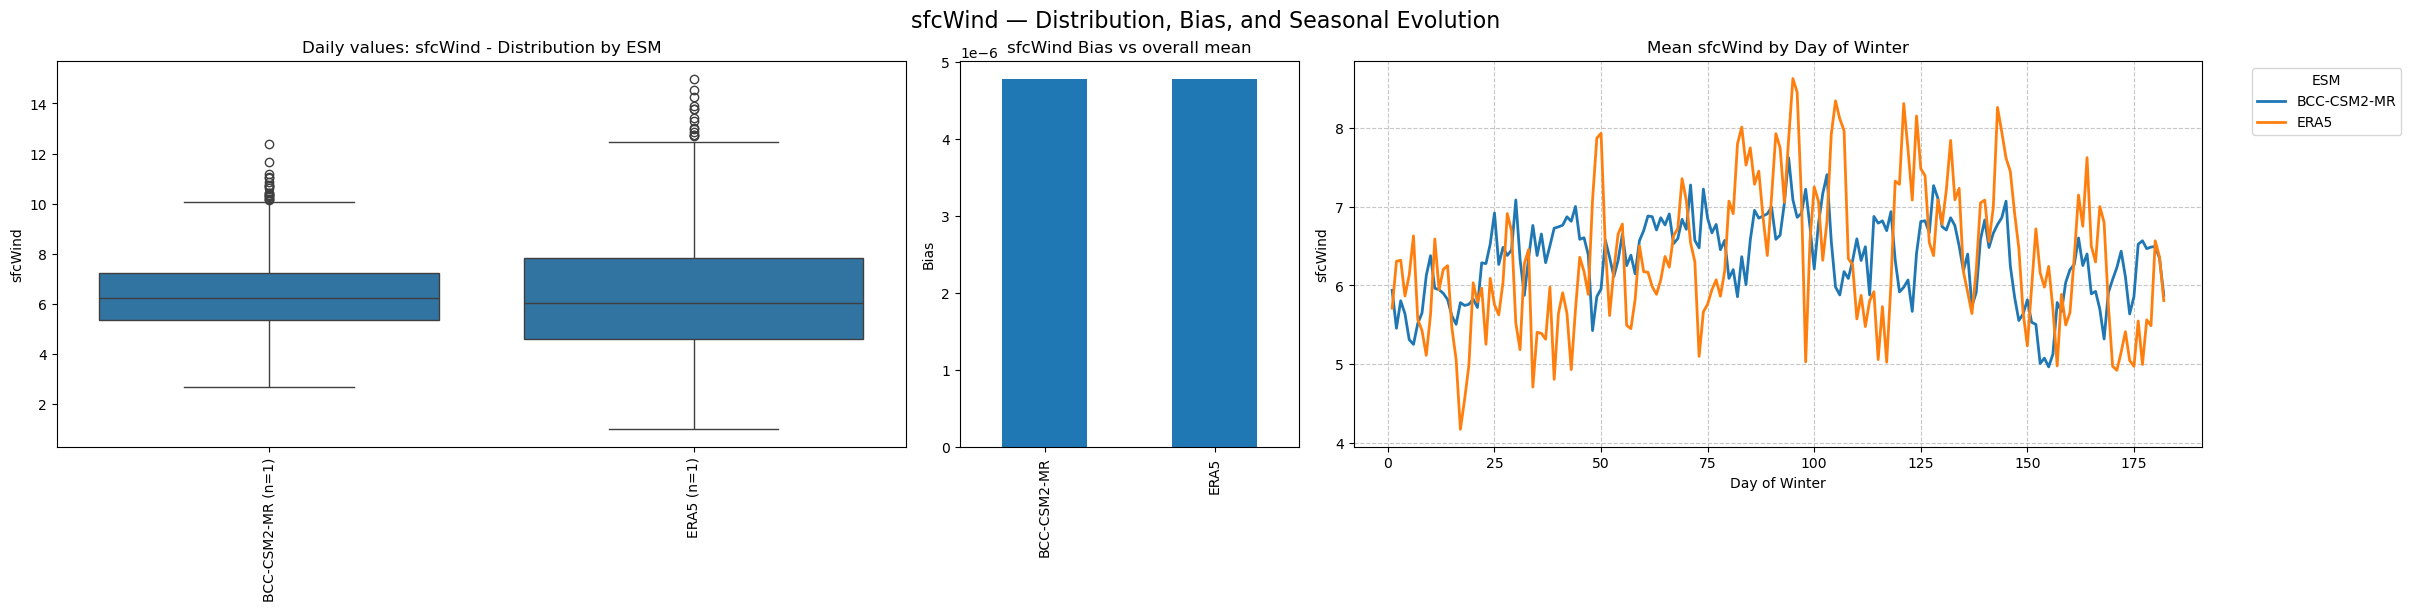

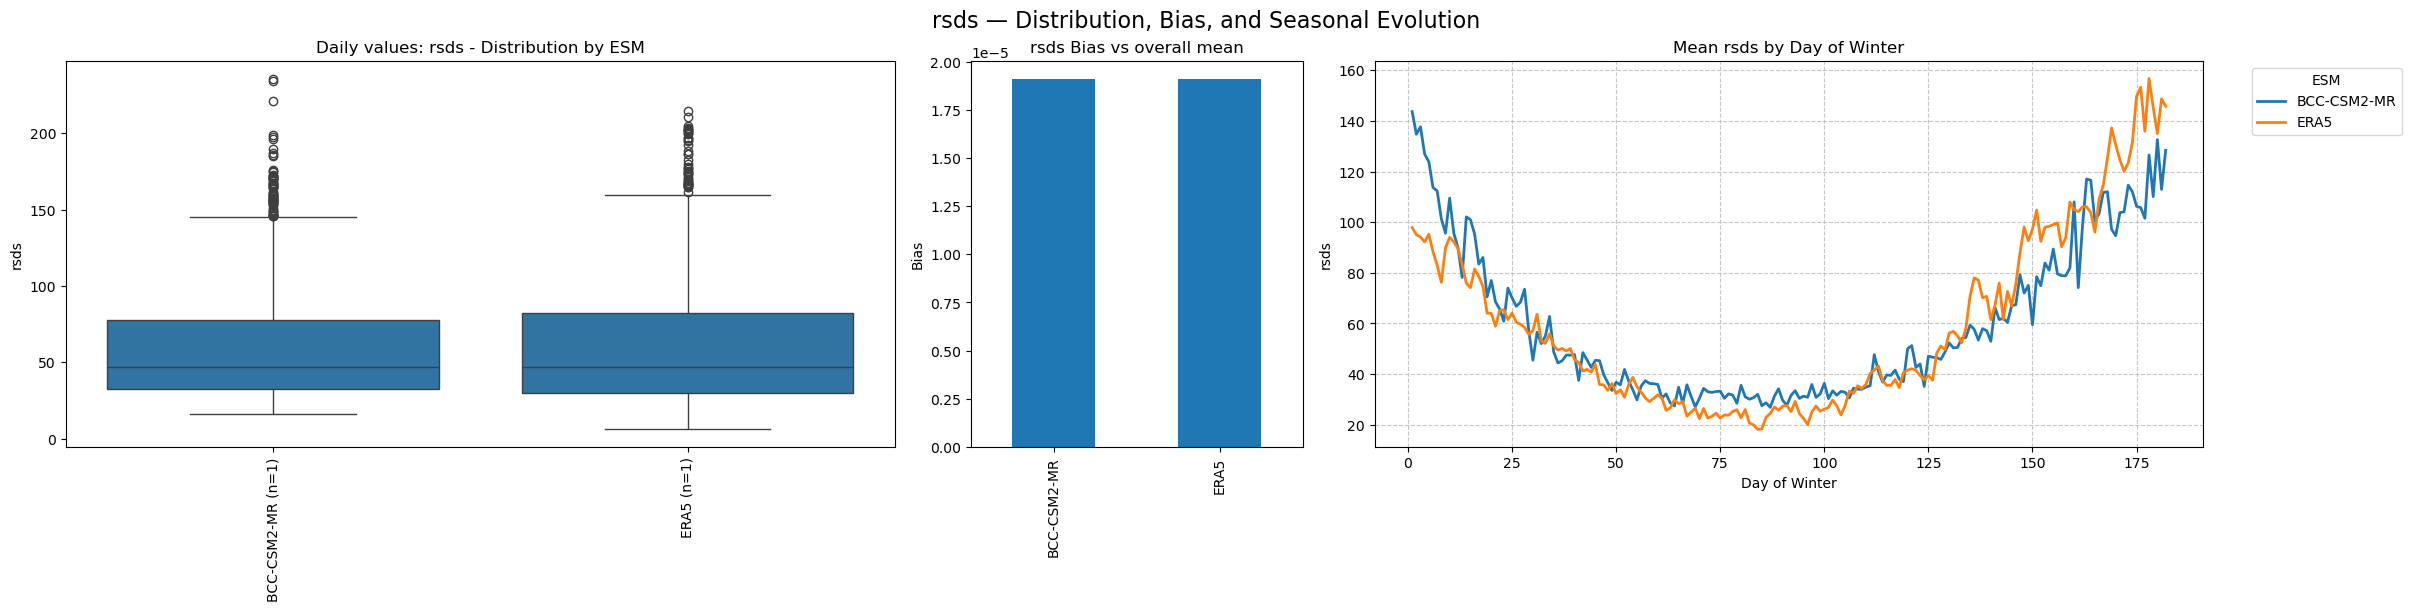

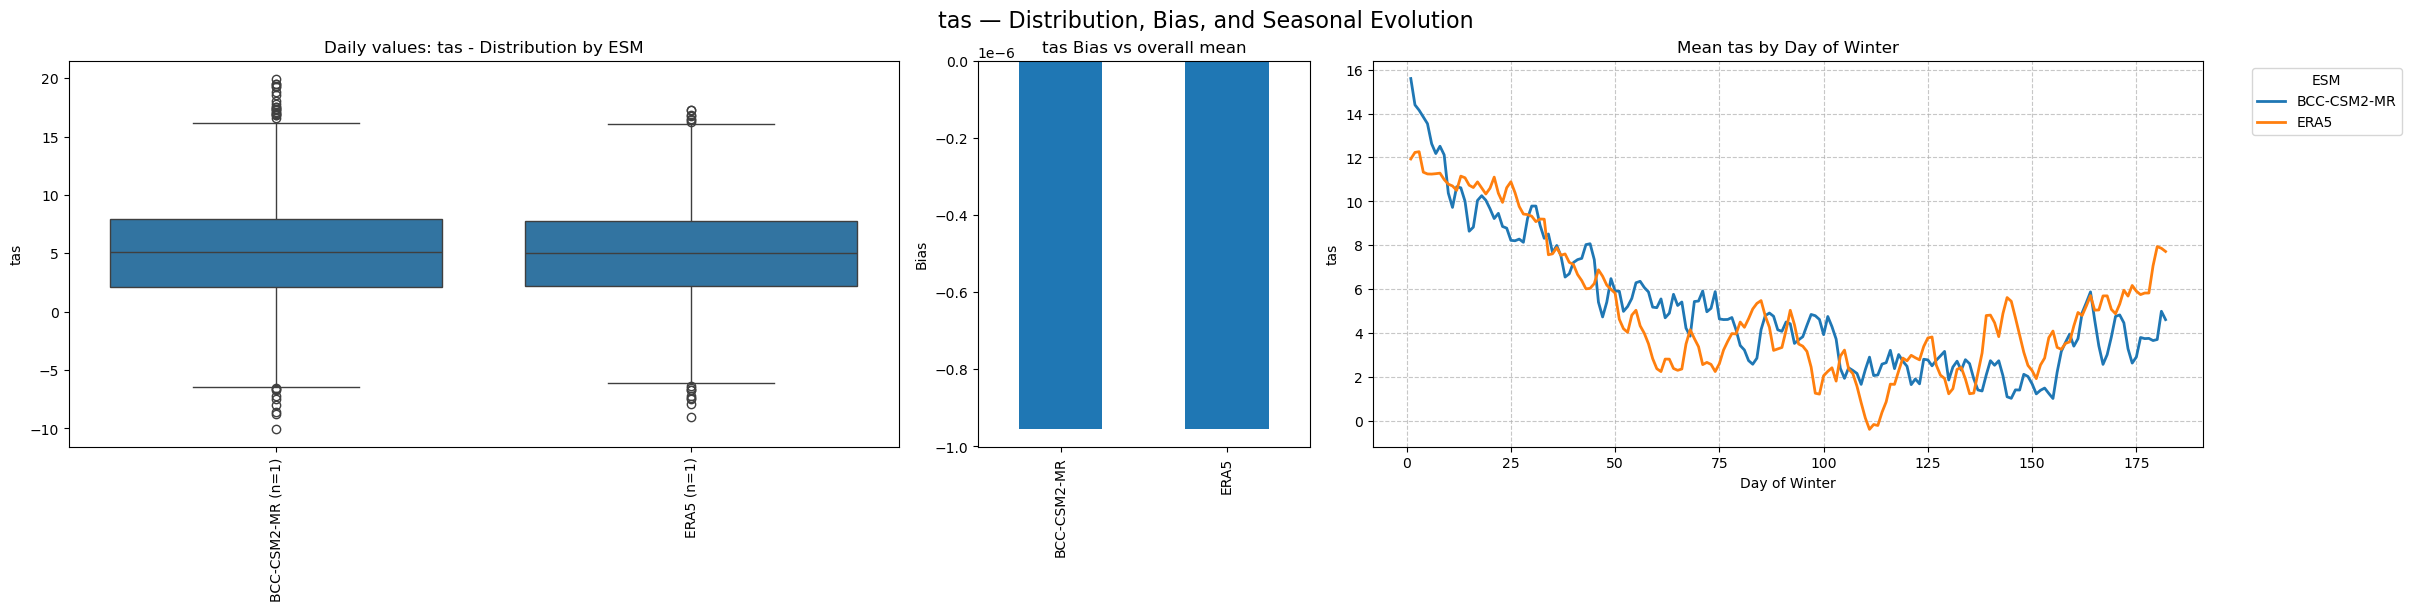

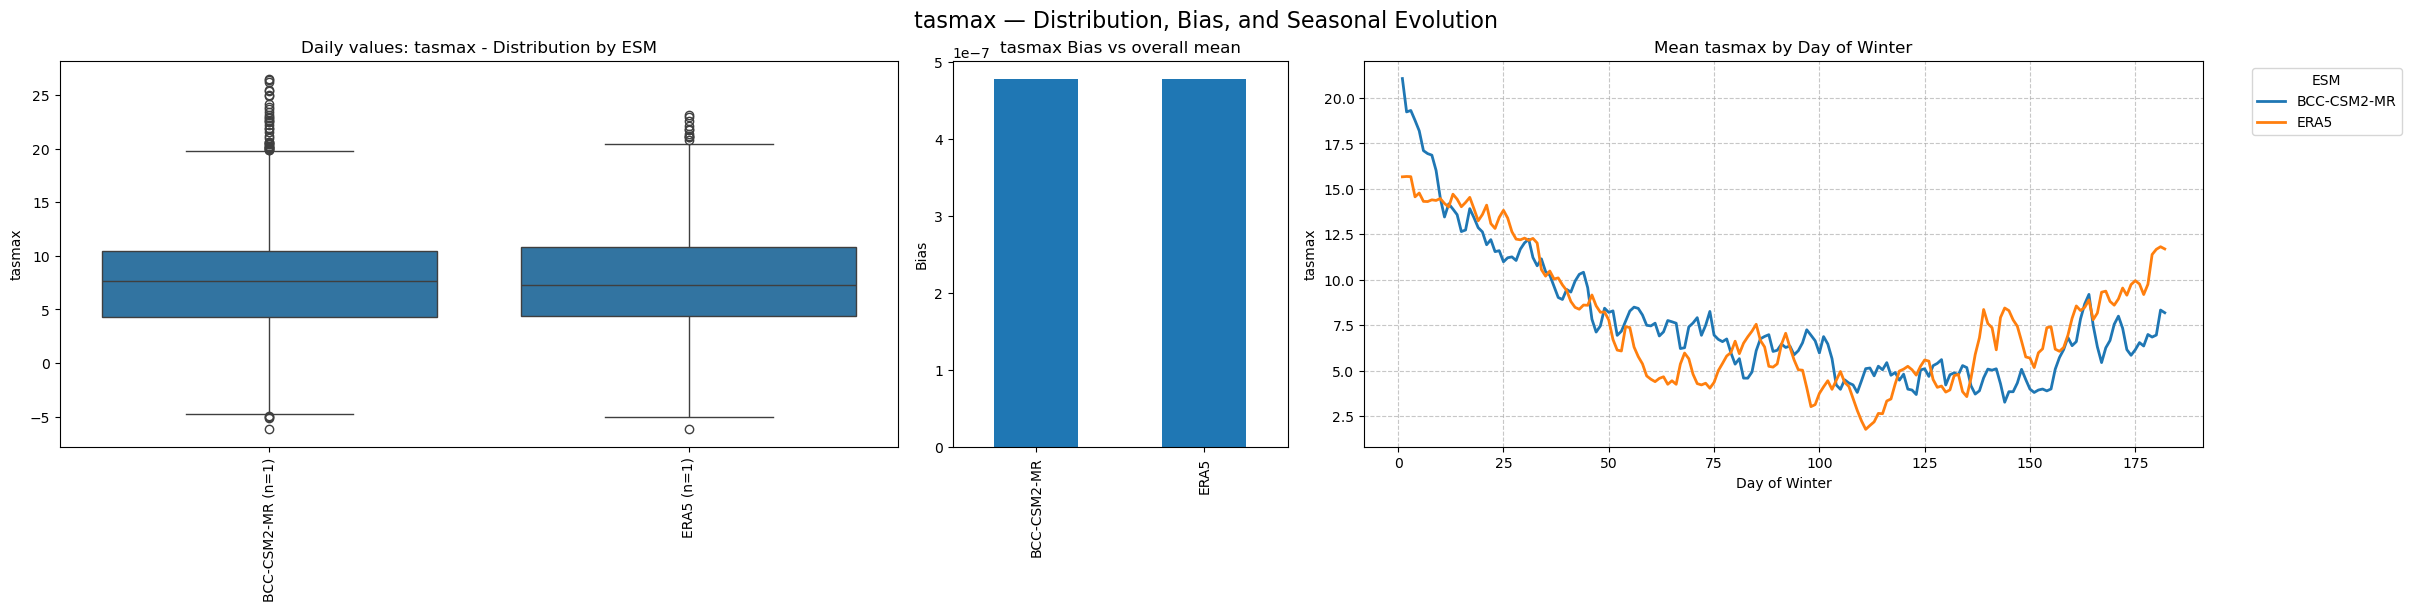

In [2]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import time
import re
import cftime

import Functions.grid_func as grid_func
import Functions.winter_date_func as winter_date_func
import Functions.wind_model_func as wind_model_func
import Functions.solar_model_func as solar_model_func
import Functions.demand as demand_func
import Functions.config as config

### Load datasets
# Load installed capacity data
grid_offshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic.nc')
grid_offshore = grid_offshore['wind_off_cap']
mask_offshore = xr.where(np.isfinite(grid_offshore), 1, 0)
grid_onshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic.nc')
grid_onshore = grid_onshore['wind_on_cap']
mask_onshore = xr.where(np.isfinite(grid_onshore), 1, 0)
grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic.nc')
grid_solar = grid_solar['solar_cap']
mask_solar = xr.where(np.isfinite(grid_solar), 1, 0)
population = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')
population = population['population']
mask_population = xr.where(np.isfinite(population), 1, 0)
# Overall mask
overall_mask = mask_offshore + mask_onshore + mask_solar + mask_population
overall_mask = xr.where(overall_mask > 0, 1, 0)
# mask
# Load climate data

MIP = 'ScenarioMIP' # CMIP
Institution = '*'
# ESMs = ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'GFDL-ESM4', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'KACE-1-0-G', 'TaiESM1', 'UKESM1-0-LL'] # 'EC-Earth3-Veg'
ESMs = ['BCC-CSM2-MR'] 

scenario = 'ssp370'
time_res = 'day'
variables = ['sfcWind', 'rsds', 'tas', 'tasmax'] # List of variables
grid_def = '*'
version = '*'
# Takes about 
for ESM in ESMs:
    print('ESM: ', ESM)
    path = f'/climca/data/CMIP6/{MIP}/{Institution}/{ESM}/{scenario}/'
    matching_dirs = glob.glob(path)
    if len(matching_dirs) == 1:
        runs = os.listdir(matching_dirs[0])
        # continue # Only for the last model
    elif len(matching_dirs) >= 1:
        runs = os.listdir(matching_dirs[0]) + os.listdir(matching_dirs[1])
    else:
        print(f"Found {len(matching_dirs)} matching directories for {ESM} and {scenario}")
        break
    print('Runs: ', runs)
    for run in runs:
        ds_list = [] # List to hold individual datasets (one for each variable)

        run_time = time.time()
        print('Run: ', run, 'Number: ', runs.index(run) + 1, 'of ', len(runs))
        run_path = os.path.join(matching_dirs[0], run, 'day/') # Watch out for last model (then manually change to matching_dirs[1])
        
        # Check if all required folders (in `variables`) exist
        missing_folders = [var for var in variables if not os.path.isdir(os.path.join(run_path, var))]
        
        if missing_folders:
            print(f"Missing folders in {run_path}: {missing_folders}")
            continue
        
        missing_data = [
            var for var in variables 
            if not os.path.isdir(os.path.join(run_path, var)) or 
               not any(
                   os.path.isfile(f) 
                   for f in glob.glob(os.path.join(run_path, var, '*', '*', '*'))  # glob pattern to match files two levels down
               )
        ]
        
        if missing_data:
            print(f"Missing data in {run_path}: {missing_data}")
            continue
        
        for variable in variables:
            # print('Variable: ', variable)
            #path =f'/climca/data/CMIP6/CMIP/NCAR/{ESM}/{scenario}/{run}/day/{variable}/gn/v20190308/{variable}_day_{ESM}_{scenario}_{run}_gn_*'
            path = f'/climca/data/CMIP6/{MIP}/{Institution}/{ESM}/{scenario}/{run}/{time_res}/{variable}/{grid_def}/{version}/{variable}_{time_res}_{ESM}_{scenario}_{run}_*'
            # print('Open: ', path)
            
            # Filter out files with extensions after .nc
            files = [f for f in glob.glob(path) if f.endswith('.nc')]
            
            # Open with preprocessing (spatial filtering)
            if files:
                nc = xr.open_mfdataset(files, preprocess=grid_func.preprocess)
            else:
                print("No valid .nc files found!")
            # nc = xr.open_mfdataset(path, preprocess=grid_func.preprocess)
                
        #     # Keep only the desired variable, but retain Dataset structure
            nc = nc[[variable]]

            # Filter years
            nc = nc.sel(time=nc.time.dt.year.isin(range(2015, 2025)))

        #     # Append to list for later merging
            ds_list.append(nc)
            
            ds_list = [ds.drop_vars('height') if 'height' in ds.coords else ds for ds in ds_list]

        # # Combine all into a single dataset
        clim_ds = xr.merge(ds_list)
                
        if ds_list[2]['tas'].units == 'K':
            clim_ds['tas'] = clim_ds['tas'] - 273.15
        
        if ds_list[3]['tasmax'].units == 'K':
            clim_ds['tasmax'] = clim_ds['tasmax'] - 273.15
        
        # Regrid the combined dataset
        combined_ds = grid_func.regrid(clim_ds)
        
        timeseries_ds = xr.Dataset()

        # timeseries_ds['sfcWind_masked'] = combined_ds['sfcWind'].mean(dim=['lat', 'lon'])
        # timeseries_ds['rsds_masked']    = combined_ds['rsds'].mean(dim=['lat', 'lon'])
        # timeseries_ds['tas_masked']     = combined_ds['tas'].mean(dim=['lat', 'lon'])
        # timeseries_ds['tasmax_masked']  = combined_ds['tasmax'].mean(dim=['lat', 'lon'])

        timeseries_ds['sfcWind_masked'] = combined_ds['sfcWind'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['rsds_masked']    = combined_ds['rsds'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['tas_masked']     = combined_ds['tas'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['tasmax_masked']  = combined_ds['tasmax'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)

        # timeseries_ds['sfcWind_masked'] = (combined_ds['sfcWind'] * overall_mask).mean(dim=['lat', 'lon'])
        # timeseries_ds['rsds_masked']    = (combined_ds['rsds'] * overall_mask).mean(dim=['lat', 'lon'])
        # timeseries_ds['tas_masked']     = (combined_ds['tas'] * overall_mask).mean(dim=['lat', 'lon'])
        # timeseries_ds['tasmax_masked']  = (combined_ds['tasmax'] * overall_mask).mean(dim=['lat', 'lon'])
        
        ts_output = timeseries_ds.assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')

        # print('Load')
        ts_output.load()
        # print('Saving')
        # ts_output.to_netcdf(f'/climca/people/onennecke/model_output/var_means/full_year/{ESM}_{run}_timeseries.nc')
        # ts_output.to_netcdf(f'/climca/people/onennecke/model_output/var_means_masked/full_year/{ESM}_{run}_timeseries.nc')
        
        print('Run time: ', int(np.floor((time.time()  - run_time) / 60)),'m', round((time.time()  - run_time) % 60,1),'s')
        # print('Finished saving')
    #     break
    # break

ts_ds_win_in = winter_date_func.add_winter_calendar(ts_output)
ts_win_in = ts_ds_win_in.sel(time=ts_ds_win_in['day_of_winter'].isin(range(1, 183)))

# Same for ERA5
variable = 't2m'
variables = ['U100', 'V100', 'SSRD', 'tas', 'tmax'] # List of variables
# path = f'/climca/data/ERA5/daily/{variables[3]}/' # Only for tmax und zum checken der anderen Variablen
path = '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/*'
matching_dirs = glob.glob(path)
all_files = [f for f in glob.glob(path) if f.endswith('.nc')]
all_files = sorted(all_files)
# Select all files in the range 2014-2024
path = '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/*'
year_range = (2015, 2024)
all_files = [f for f in glob.glob(path) if f.endswith('.nc')]
all_files = sorted(all_files)

filtered_files = []
for file in all_files:
    # Extract year and month using regex
    match = re.search(r'(\d{4})', file)
    if match:
        year = int(match.group(1))
        if year_range is None or year_range[0] <= year <= year_range[1]:
            filtered_files.append(file)

filtered_files

# Read datasets for each variable
files_by_variable = {}

# Group files by variable name
for f in filtered_files:
    match = re.search(r'/([^/]+)_(\d{4})\.nc$', f)
    if match:
        var = match.group(1)
        if var not in files_by_variable:
            files_by_variable[var] = []
        files_by_variable[var].append(f)

files_by_variable
# SSRD_list = files_by_variable['SSRD']
# SSRD_list

# Read datasets for each variable
datasets_by_variable = {}
for var, files in files_by_variable.items():
    # print(f'Processing {var}...')
    files_sorted = sorted(files)

    # Use the first file as coordinate reference
    ref_ds = xr.open_dataset(files_sorted[0])
    ref_lat = ref_ds.lat
    ref_lon = ref_ds.lon

    def preprocess(ds):
        ds = ds.sortby('lat')  # Ensure consistent order
        ds = ds.assign_coords(lat=ref_lat, lon=ref_lon)  # Align coordinates exactly
        return ds

    # Open and process all datasets with aligned coordinates
    ds = xr.open_mfdataset(files_sorted, combine='by_coords', preprocess=preprocess)
    
    if var == 'SSRD':
        ds = ds / 3600 # Convert from J/m2 to W/m2
    ds_daily = ds.resample(time='1D').mean()
    datasets_by_variable[var] = ds_daily
    if var == 'tas':
        tasmax = ds.resample(time='1D').max()
        tasmax = tasmax.rename({'var167': 'tasmax'})
        datasets_by_variable['tasmax'] = tasmax


datasets_by_variable

var_names = {'var169': 'rsds',
             'var167': 'tas',
             'var246': 'U100',
             'var247': 'V100',
             'tasmax': 'tasmax'}

ds_list = []

for i in datasets_by_variable:
    ds = datasets_by_variable[i]
    var = list(ds.data_vars)[0]
    ds = ds.rename({var: var_names[var]})
    ds = ds.sel(lat=slice(45, 60), lon=slice(4, 17))
    nc = grid_func.regrid(ds, s = 47, n = 56, w = 5, e = 17) # One ° less in the north to prevent NaN values
    # Append to list for later merging
    ds_list.append(nc)

# Read in tmax

# Combine all into a single dataset
clim_ds = xr.merge(ds_list)

clim_ds['wind_speed'] = np.sqrt(clim_ds['U100']**2 + clim_ds['V100']**2)
clim_ds['tas'] = clim_ds['tas'] - 273.15
clim_ds['tasmax'] = clim_ds['tasmax'] - 273.15

combined_ds = clim_ds
combined_ds

timeseries_ds = xr.Dataset()

# timeseries_ds['sfcWind_masked'] = combined_ds['wind_speed'].mean(dim=['lat', 'lon'])
# timeseries_ds['rsds_masked']    = combined_ds['rsds'].mean(dim=['lat', 'lon'])
# timeseries_ds['tas_masked']     = combined_ds['tas'].mean(dim=['lat', 'lon'])
# timeseries_ds['tasmax_masked']  = combined_ds['tasmax'].mean(dim=['lat', 'lon'])

timeseries_ds['sfcWind_masked'] = combined_ds['wind_speed'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
timeseries_ds['rsds_masked']    = combined_ds['rsds'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
timeseries_ds['tas_masked']     = combined_ds['tas'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
timeseries_ds['tasmax_masked']  = combined_ds['tasmax'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)

# timeseries_ds['sfcWind_masked'] = (combined_ds['wind_speed'] * overall_mask).mean(dim=['lat', 'lon'])
# timeseries_ds['rsds_masked']    = (combined_ds['rsds'] * overall_mask).mean(dim=['lat', 'lon'])
# timeseries_ds['tas_masked']     = (combined_ds['tas'] * overall_mask).mean(dim=['lat', 'lon'])
# timeseries_ds['tasmax_masked']  = (combined_ds['tasmax'] * overall_mask).mean(dim=['lat', 'lon'])

ts_output = timeseries_ds.assign_coords(run = 'hist', ESM = 'ERA5', ESM_run = 'ERA5_hist') # , country = 9.0, period = 'week'
# print('Load')
ts_output.load()
# print('Saving')
# ts_output.to_netcdf('/climca/people/onennecke/model_output/var_means_masked/full_year/ERA5_timeseries.nc')


# print('Finished saving')

ts_ds_win_ERA5 = winter_date_func.add_winter_calendar(ts_output)
ts_win_ERA5 = ts_ds_win_ERA5.sel(time=ts_ds_win_ERA5['day_of_winter'].isin(range(1, 183)))

## Fix time format for ERA5
ts_win_ERA5 = ts_win_ERA5.assign_coords(time=ts_win_in['time'].values)
# Combine both datasets
ts_datasets = xr.concat([ts_win_in, ts_win_ERA5], dim='ESM_run')
ts_datasets
all_dfs = []
variables = [
    'sfcWind_masked', 'rsds_masked', 'tas_masked', 'tasmax_masked' # , 'temp', 'demand', 'demand_weekly', 'wind_off_prod', 'wind_on_prod', 'solar_prod', 'total_prod', 'Residual_load'
]
for var in variables:
    ERA5_mean = ts_datasets[var].sel(ESM_run='ERA5_hist').mean('time')
    model_mean = ts_datasets[var].groupby('ESM').mean().mean('time')
    # overall_mean = ts_datasets[var].mean('time').mean()
    
    overall_mean = ts_datasets[var].mean('time').mean('ESM_run')
    
    bias = model_mean - ERA5_mean
    
    df_bias = pd.DataFrame({
        'ESM': np.unique(ts_datasets['ESM'].values),
        # 'ERA5_mean': ERA5_mean.values,
        f'model_mean_{var}': model_mean.values,
        f'overall_mean_{var}': overall_mean.values,
        f'bias_{var}': bias.values
    })
    all_dfs.append(df_bias)
final_df_bias = pd.concat(all_dfs, axis=1, ignore_index=False)
final_df_bias = final_df_bias.loc[:,~final_df_bias.columns.duplicated()]
final_df_bias


### Load datasets
# Load installed capacity data
grid_offshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic.nc')
grid_offshore = grid_offshore['wind_off_cap']
mask_offshore = xr.where(np.isfinite(grid_offshore), 1, 0)
grid_onshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic.nc')
grid_onshore = grid_onshore['wind_on_cap']
mask_onshore = xr.where(np.isfinite(grid_onshore), 1, 0)
grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic.nc')
grid_solar = grid_solar['solar_cap']
mask_solar = xr.where(np.isfinite(grid_solar), 1, 0)
population = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')
population = population['population']
mask_population = xr.where(np.isfinite(population), 1, 0)
# Overall mask
overall_mask = mask_offshore + mask_onshore + mask_solar + mask_population
overall_mask = xr.where(overall_mask > 0, 1, 0)
# Load wind height data
grid_onsh_hub_height = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_height_weighted.nc')
grid_offsh_hub_height = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted.nc')

hub_height_on = grid_onsh_hub_height['wind_on_hub_height']
hub_height_off = grid_offsh_hub_height['wind_off_hub_height']
# Load regridded population weights data
pop_regr_CIESIN_weights = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')

# Load fit values from vdW Paper
demand_fit_values = xr.open_dataset('/climca/people/onennecke/population_data/demand_fit_values_week.nc')
# Load bias data
# biases = pd.read_csv('/climca/people/onennecke/model_output/var_means/biases.csv')
biases = final_df_bias# pd.read_csv('/climca/people/onennecke/model_output/var_means_masked/biases.csv')

biases
### Define used models
# Load climate data

MIP = 'ScenarioMIP' # CMIP
Institution = '*'

# ESMs = ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'GFDL-ESM4', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'KACE-1-0-G', 'TaiESM1', 'UKESM1-0-LL'] # 'EC-Earth3-Veg'
ESMs = ['BCC-CSM2-MR'] # 'EC-Earth3-Veg'

scenario = 'ssp370'
time_res = 'day'
variables = ['sfcWind', 'rsds', 'tas', 'tasmax'] # List of variables
grid_def = '*'
version = '*'

# Takes about 
for ESM in ESMs:
    print('ESM: ', ESM)
    path = f'/climca/data/CMIP6/{MIP}/{Institution}/{ESM}/{scenario}/'
    matching_dirs = glob.glob(path)
    if len(matching_dirs) == 1:
        runs = os.listdir(matching_dirs[0])
        # continue # Only for the last model
    elif len(matching_dirs) >= 1:
        runs = os.listdir(matching_dirs[0]) + os.listdir(matching_dirs[1])
    else:
        print(f"Found {len(matching_dirs)} matching directories for {ESM} and {scenario}")
        break
    print('Runs: ', runs)
    for run in runs:
        ds_list = [] # List to hold individual datasets (one for each variable)

        run_time = time.time()
        print('Run: ', run, 'Number: ', runs.index(run) + 1, 'of ', len(runs))
        run_path = os.path.join(matching_dirs[0], run, 'day/') # Watch out for last model (then manually change to matching_dirs[1])
        
        # Check if all required folders (in `variables`) exist
        missing_folders = [var for var in variables if not os.path.isdir(os.path.join(run_path, var))]
        
        if missing_folders:
            print(f"Missing folders in {run_path}: {missing_folders}")
            continue
        
        missing_data = [
            var for var in variables 
            if not os.path.isdir(os.path.join(run_path, var)) or 
               not any(
                   os.path.isfile(f) 
                   for f in glob.glob(os.path.join(run_path, var, '*', '*', '*'))  # glob pattern to match files two levels down
               )
        ]
        
        if missing_data:
            print(f"Missing data in {run_path}: {missing_data}")
            continue
        
        for variable in variables:
            # print('Variable: ', variable)
            #path =f'/climca/data/CMIP6/CMIP/NCAR/{ESM}/{scenario}/{run}/day/{variable}/gn/v20190308/{variable}_day_{ESM}_{scenario}_{run}_gn_*'
            path = f'/climca/data/CMIP6/{MIP}/{Institution}/{ESM}/{scenario}/{run}/{time_res}/{variable}/{grid_def}/{version}/{variable}_{time_res}_{ESM}_{scenario}_{run}_*'
            # print('Open: ', path)
            
            # Filter out files with extensions after .nc
            files = [f for f in glob.glob(path) if f.endswith('.nc')]
            
            # Open with preprocessing (spatial filtering)
            if files:
                nc = xr.open_mfdataset(files, preprocess=grid_func.preprocess)
            else:
                print("No valid .nc files found!")
            # nc = xr.open_mfdataset(path, preprocess=grid_func.preprocess)
                
        #     # Keep only the desired variable, but retain Dataset structure
            nc = nc[[variable]]
            
            
        #     # Filter to only winter months (October to March)
        #     # nc = nc.sel(time=nc.time.dt.month.isin([10, 11, 12, 1, 2, 3]))

            # Filter years
            nc = nc.sel(time=nc.time.dt.year.isin(range(2015, 2025)))
            
        #     # Append to list for later merging
            ds_list.append(nc)
            
            ds_list = [ds.drop_vars('height') if 'height' in ds.coords else ds for ds in ds_list]

        # # Combine all into a single dataset
        clim_ds = xr.merge(ds_list)
                
        if ds_list[2]['tas'].units == 'K':
            clim_ds['tas'] = clim_ds['tas'] - 273.15
        
        if ds_list[3]['tasmax'].units == 'K':
            clim_ds['tasmax'] = clim_ds['tasmax'] - 273.15
            
        # Apply bias correction
        clim_ds['sfcWind'] = clim_ds['sfcWind'] - biases.loc[biases['ESM'] == ESM, 'bias_sfcWind_masked'].values[0]
        clim_ds['rsds'] = clim_ds['rsds'] - biases.loc[biases['ESM'] == ESM, 'bias_rsds_masked'].values[0]
        clim_ds['tas'] = clim_ds['tas'] - biases.loc[biases['ESM'] == ESM, 'bias_tas_masked'].values[0]
        clim_ds['tasmax'] = clim_ds['tasmax'] - biases.loc[biases['ESM'] == ESM, 'bias_tasmax_masked'].values[0]
            
        # Regrid the combined dataset
        combined_ds = grid_func.regrid(clim_ds)
        
        wepot_off = wind_model_func.compute_wind_energy_potential(combined_ds['sfcWind'], grid_offsh_hub_height, config.a_offshore, config.height_ref)
        wepot_on = wind_model_func.compute_wind_energy_potential(combined_ds['sfcWind'], grid_onsh_hub_height, config.a_onshore, config.height_ref)
        
        combined_ds['wind_off_pot'] = wepot_off['wind_off_pot']
        combined_ds['wind_on_pot'] = wepot_on['wind_on_pot']
        
        weprod_off = wind_model_func.compute_wind_energy_production(wepot_off, grid_offshore)
        weprod_on = wind_model_func.compute_wind_energy_production(wepot_on, grid_onshore)
        
        combined_ds['wind_off_prod'] = weprod_off['wind_off_prod']
        combined_ds['wind_on_prod'] = weprod_on['wind_on_prod']
        
        sepot = solar_model_func.compute_solar_energy_potential(combined_ds['rsds'], combined_ds['tas'], combined_ds['tasmax'], combined_ds['sfcWind'])
        
        # combined_ds['solar_pot'] = sepot['solar_pot']        
        combined_ds['solar_pot'] = sepot
        
        seprod = solar_model_func.compute_solar_energy_production(sepot, grid_solar)
        
        # combined_ds['solar_prod'] = seprod['solar_prod']
        combined_ds['solar_prod'] = seprod

        
        # Calculate weighted sum

        weighted_temp_list = []
        for y in np.unique(combined_ds['tas']["time.year"].values):
            # print(y)
            ds_weigh_temp_0 = xr.Dataset()
            ds_weigh_temp_0['temp'] = (combined_ds['tas'].sel(time=str(y)) * pop_regr_CIESIN_weights['population']).sum(dim=['lat', 'lon'])
            weighted_temp_list.append(ds_weigh_temp_0)
            
        ds_weighted_temp = xr.concat(weighted_temp_list, dim="time") 
        
        # Calculate demand
        demand_ds = demand_func.compute_demand(ds_weighted_temp, demand_fit_values.sel(country = 9, period = 'week'))
        
        timeseries_ds = demand_ds.copy()

        # timeseries_ds['sfcWind'] = combined_ds['sfcWind'].mean(dim=['lat', 'lon'])
        # timeseries_ds['rsds'] = combined_ds['rsds'].mean(dim=['lat', 'lon'])
        # timeseries_ds['tas'] = combined_ds['tas'].mean(dim=['lat', 'lon'])
        # timeseries_ds['tasmax'] = combined_ds['tasmax'].mean(dim=['lat', 'lon'])
               
        timeseries_ds['sfcWind'] = combined_ds['sfcWind'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['rsds']    = combined_ds['rsds'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['tas']     = combined_ds['tas'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['tasmax']  = combined_ds['tasmax'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        
        # timeseries_ds['sfcWind'] = (combined_ds['sfcWind'] * overall_mask).mean(dim=['lat', 'lon'])
        # timeseries_ds['rsds']    = (combined_ds['rsds'] * overall_mask).mean(dim=['lat', 'lon'])
        # timeseries_ds['tas']     = (combined_ds['tas'] * overall_mask).mean(dim=['lat', 'lon'])
        # timeseries_ds['tasmax']  = (combined_ds['tasmax'] * overall_mask).mean(dim=['lat', 'lon'])
        
        timeseries_ds['wind_off_prod'] = combined_ds['wind_off_prod'].sum(dim=['lat', 'lon']) / 1000000
        timeseries_ds['wind_on_prod'] = combined_ds['wind_on_prod'].sum(dim=['lat', 'lon']) / 1000000
        timeseries_ds['solar_prod'] = combined_ds['solar_prod'].sum(dim=['lat', 'lon']) / 1000000
        
        timeseries_ds['total_prod'] = timeseries_ds['wind_off_prod'] + timeseries_ds['wind_on_prod'] + timeseries_ds['solar_prod']
        timeseries_ds['Netto'] = timeseries_ds['total_prod'] - timeseries_ds['demand']
        timeseries_ds['Residual_load'] = timeseries_ds['demand'] - timeseries_ds['total_prod']
        
        ts_output = timeseries_ds.assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')
        # print('Load')
        ts_output.load()
        # print('Saving')
        # ts_output.to_netcdf(f'/climca/people/onennecke/model_output/bias_corrected/full_year/{ESM}_{run}_timeseries.nc')
        # ts_output.to_netcdf(f'/climca/people/onennecke/model_output/bias_corrected_masked/full_year/{ESM}_{run}_timeseries.nc')
        
        print('Run time: ', int(np.floor((time.time()  - run_time) / 60)),'m', round((time.time()  - run_time) % 60,1),'s')
        # print('Finished saving')
    #     break
    # break
ts_output

ts_ds_win_in = winter_date_func.add_winter_calendar(ts_output)
ts_win_in = ts_ds_win_in.sel(time=ts_ds_win_in['day_of_winter'].isin(range(1, 183)))
ts_win_in

path = '/climca/people/onennecke/model_output/var_means_masked/winter_data/'
# path = '/climca/people/onennecke/model_output/var_means/winter_data/'

files = sorted(glob.glob(os.path.join(path, '*.nc')))
files = files[60]#  + files[61:]
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')
# files

# Rename variables without _masked
ts_datasets = ts_datasets.rename({
    'sfcWind_masked': 'sfcWind',
    'rsds_masked': 'rsds',
    'tas_masked': 'tas',
    'tasmax_masked': 'tasmax'
})
ts_datasets['time'] = ts_win_in['time']

ts_datasets.load()
ts_datasets = xr.concat([ts_win_in, ts_datasets], dim='ESM_run')
ts_datasets
# Group data by ESMs and calculate mean temp, demand, wind, ...
all_dfs = []
for esm in np.unique(ts_datasets['ESM'].values):
    filtered_dataset = ts_datasets.where(ts_datasets['ESM'] == esm, drop=True)
    mean_by_day = filtered_dataset.groupby('day_of_winter').mean(dim=['time', 'ESM_run'])
    df = pd.DataFrame({
        'day_of_winter': mean_by_day['day_of_winter'].values,
        'temp': mean_by_day['temp'].values,
        'demand': mean_by_day['demand'].values,
        # 'demand_weekly': mean_by_day['demand_weekly'].values,
        'sfcWind': mean_by_day['sfcWind'].values,
        'rsds' : mean_by_day['rsds'].values,
        'tas': mean_by_day['tas'].values,
        'tasmax': mean_by_day['tasmax'].values,
        'wind_off_prod': mean_by_day['wind_off_prod'].values,
        'wind_on_prod': mean_by_day['wind_on_prod'].values,
        'solar_prod': mean_by_day['solar_prod'].values,
        'total_prod': mean_by_day['total_prod'].values,
        'netto': mean_by_day['Netto'].values,
        'Residual_load': mean_by_day['Residual_load'].values,
    })
    df['ESM'] = esm
    all_dfs.append(df)

final_df = pd.concat(all_dfs, ignore_index=True)

final_df
# For Boxplots per model
df = ts_datasets.to_dataframe().reset_index()

variables = [
    'sfcWind', 'rsds', 'tas', 'tasmax', 'temp', 'demand',
    'wind_off_prod', 'wind_on_prod', 'solar_prod',
    'total_prod', 'Residual_load'
]

# Compute ESM counts once and create labels
esm_counts = (df['ESM'].value_counts().sort_index() // 1820).astype(int)
esm_label_map = {esm: f"{esm} (n={count})" for esm, count in esm_counts.items()}
df['ESM_label'] = df['ESM'].map(esm_label_map)
all_dfs = []
variables = [
    'sfcWind', 'rsds', 'tas', 'tasmax' # , 'temp', 'demand', 'demand_weekly', 'wind_off_prod', 'wind_on_prod', 'solar_prod', 'total_prod', 'Residual_load'
]
for var in variables:
    ERA5_mean = ts_datasets[var].sel(ESM_run='ERA5_hist').mean('time')
    model_mean = ts_datasets[var].groupby('ESM').mean().mean('time')
    # overall_mean = ts_datasets[var].mean('time').mean()
    
    overall_mean = ts_datasets[var].mean('time').mean('ESM_run')
    
    bias = model_mean - ERA5_mean
    
    df_bias = pd.DataFrame({
        'ESM': np.unique(ts_datasets['ESM'].values),
        # 'ERA5_mean': ERA5_mean.values,
        f'model_mean_{var}': model_mean.values,
        f'overall_mean_{var}': overall_mean.values,
        f'bias_{var}': bias.values
    })
    all_dfs.append(df_bias)
final_df_bias = pd.concat(all_dfs, axis=1, ignore_index=False)
final_df_bias = final_df_bias.loc[:,~final_df_bias.columns.duplicated()]
final_df_bias

# Loop over variables and plot boxplot, bias, and seasonal lineplot
for var in variables:
    fig, axes = plt.subplots(
        1, 3,
        figsize=(24, 6),
        gridspec_kw={'width_ratios': [3, 1.2, 3]},
        constrained_layout=True
    )

    # 1. Boxplot (left)
    sns.boxplot(data=df, x='ESM_label', y=var, ax=axes[0])
    axes[0].set_title(f'Daily values: {var} - Distribution by ESM')
    axes[0].tick_params(axis='x', rotation=90)
    axes[0].set_xlabel('')
    axes[0].set_ylabel(var)

    # 2. Bias barplot (middle)

    model_mean = ts_datasets[var].groupby('ESM').mean().mean('time')
    overall_mean = ts_datasets[var].mean('time').mean()
    bias = model_mean - overall_mean

    bias.to_series().plot.bar(ax=axes[1])
    axes[1].set_title(f'{var} Bias vs overall mean')
    axes[1].set_ylabel('Bias')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=90)


    # 3. Line plot (right)

    if var in final_df.columns:
        for esm, group in final_df.groupby('ESM'):
            if esm == 'ERA5_week':
                axes[2].plot(group['day_of_winter'], group[var], color='red', linewidth=3, label='ERA5')
            elif esm == 'ERA5_wwd':
                axes[2].plot(group['day_of_winter'], group[var], color='red', linewidth=1, label='ERA5 wwd')
            else:
                axes[2].plot(group['day_of_winter'], group[var], linewidth=2, label=esm)

        axes[2].set_title(f'Mean {var} by Day of Winter')
        axes[2].set_xlabel('Day of Winter')
        axes[2].set_ylabel(var)
        axes[2].grid(True, linestyle='--', alpha=0.7)
        axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title='ESM')
    else:
        axes[2].text(0.5, 0.5, f'{var} not in final_df', ha='center', va='center')
        axes[2].set_axis_off()


    # Title
    plt.suptitle(f'{var} — Distribution, Bias, and Seasonal Evolution', fontsize=16)
    plt.show()

